In [20718]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Data import

In [20719]:
df = pd.read_csv(
    r'C:\Users\elias\Desktop\JULY 10ALYSTIC NOVA PROJECT\Novapay-fraudulent\data\nova_pay_combined.csv'
)

In [20720]:
df.head() # Display the first 5 rows of the DataFrame

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [20721]:
df.tail(5) # Display the last 5 rows of the DataFrame

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
11395,b5ef3323-46d2-4f6c-9c19-43df4e55df48,8734e6a7-f34e-49f2-b559-1d62a756664c,2025-11-25 10:05:35.573611+00:00,US,USD,CAD,mobile,271.25,271.25,5.24,...,0.307,standard,742,0.653,0,0.302,1,2,0.00,0
11396,54f00f78-94aa-4a08-bf6b-12877aa47186,c18070a6-bdb9-4df3-9df7-5d92c0bff424,2025-11-26 07:09:56.573611+00:00,CA,CAD,NGN,web,537.17,397.51,8.86,...,0.891,low,9,0.173,2,0.730,3,6,0.00,1
11397,6a51f0e8-f5d1-4fe6-91a0-655fccd79fa5,2003e2a1-f3b1-4e2e-8d0e-488cfacf68ca,2025-11-27 06:19:11.573611+00:00,CA,CAD,INR,web,205.15,151.81,4.00,...,1.000,low,21,0.269,1,0.605,3,4,0.12,1
11398,4aad7389-2b62-4885-a23e-aa3ecd5cfaf9,8b1cf558-4ed7-48ee-b330-75db6efd4840,2025-11-28 00:53:28.573611+00:00,US,USD,PHP,mobile,78.03,78.03,1.96,...,0.298,enhanced,471,0.773,0,0.375,0,2,0.00,0
11399,fdffeb16-192a-4483-9b1e-9928e23269c2,b69010dc-ab0a-4fd2-a79e-65e4c6efbcd9,2025-11-29 20:10:47.573611+00:00,US,USD,NGN,web,1214.16,1214.16,19.34,...,1.000,low,58,0.187,0,0.646,4,6,0.25,1


In [20722]:
df.info() # Display concise summary of the DataFrame, including data types and non-null counts

<class 'pandas.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  str    
 1   customer_id                11400 non-null  str    
 2   timestamp                  11371 non-null  str    
 3   home_country               11400 non-null  str    
 4   source_currency            11400 non-null  str    
 5   dest_currency              11400 non-null  str    
 6   channel                    11400 non-null  str    
 7   amount_src                 11400 non-null  str    
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  str    
 12  new_device                 11400 non-null  bool   
 13  ip_address                 11095 non-null  str    
 14  i

This dataset contains missing information in several variables, indicating that some transaction records are incomplete. The highest number of missing values is found in the amount_usd and ip_address columns, with 305 missing entries each. Other variables, including ip_country, kyc_tier, fee, and device_trust_score, also contain a similar number of missing records, while the timestamp column has relatively few missing values (29). 

### Investigating the Data Processing Workflow

In [20723]:
# Check for missing values in the DataFrame
missing_values = df.isnull().sum()
missing = missing_values[missing_values > 0]

print("Missing values in each column:")
print(missing)

Missing values in each column:
timestamp              29
amount_usd            305
fee                   295
ip_address            305
ip_country            301
kyc_tier              300
device_trust_score    295
dtype: int64


In [20724]:
round(df.isnull().mean()*100, 2)

transaction_id               0.00
customer_id                  0.00
timestamp                    0.25
home_country                 0.00
source_currency              0.00
dest_currency                0.00
channel                      0.00
amount_src                   0.00
amount_usd                   2.68
fee                          2.59
exchange_rate_src_to_dest    0.00
device_id                    0.00
new_device                   0.00
ip_address                   2.68
ip_country                   2.64
location_mismatch            0.00
ip_risk_score                0.00
kyc_tier                     2.63
account_age_days             0.00
device_trust_score           2.59
chargeback_history_count     0.00
risk_score_internal          0.00
txn_velocity_1h              0.00
txn_velocity_24h             0.00
corridor_risk                0.00
is_fraud                     0.00
dtype: float64

In [20725]:
df['ip_country'].value_counts().head().index

Index(['US', 'UK', 'CA', ' US  ', 'unknown'], dtype='str', name='ip_country')

In [20726]:
df['timestamp']

0        2022-10-03 18:40:59.468549+00:00
1        2022-10-03 20:39:38.468549+00:00
2        2022-10-03 23:02:43.468549+00:00
3        2022-10-04 01:08:53.468549+00:00
4        2022-10-04 09:35:03.468549+00:00
                       ...               
11395    2025-11-25 10:05:35.573611+00:00
11396    2025-11-26 07:09:56.573611+00:00
11397    2025-11-27 06:19:11.573611+00:00
11398    2025-11-28 00:53:28.573611+00:00
11399    2025-11-29 20:10:47.573611+00:00
Name: timestamp, Length: 11400, dtype: str

In [20727]:
rate = {
    'USD': 1.0,
    'EUR': 0.85,
    'GBP': 0.75,
    'CAD': 1.5,
}

In [20728]:
df[['amount_usd', 'amount_src']].dtypes
df['amount_src'] = pd.to_numeric(df['amount_src'], errors='coerce')


In [20729]:
df['source_currency'].value_counts()

source_currency
USD    8031
GBP    2139
CAD    1230
Name: count, dtype: int64

In [20730]:
rates = round((df['amount_usd']/df['amount_src']).groupby(df['source_currency']).mean(), 1)
round((df['amount_usd']/df['amount_src']).groupby(df['source_currency']).mean(), 1)


source_currency
CAD    0.7
GBP    1.2
USD    1.0
dtype: float64

In [20731]:
df['amount_usd'] = df['amount_usd'].fillna(df['amount_src'] * df['source_currency'].map(rates))

In [20732]:
df. isnull().sum()
# Check for missing values in the DataFrame

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     4
amount_usd                     0
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   301
location_mismatch              0
ip_risk_score                  0
kyc_tier                     300
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [20734]:
#feel with mean or median
df['fee'] #fee column contains the transaction fee associated with each transaction. It represents the cost incurred for processing the transaction and is typically expressed in the source currency of the transaction. The fee can vary based on factors such as the payment method, transaction amount, and any applicable service charges.

0         4.25
1         4.24
2         2.70
3         2.22
4         3.61
         ...  
11395     5.24
11396     8.86
11397     4.00
11398     1.96
11399    19.34
Name: fee, Length: 11400, dtype: float64

In [20735]:
df['ip_country'].value_counts()

ip_country
US         6848
UK         2407
CA         1726
 US          49
unknown      33
 UK          18
 CA          15
NAN           2
 nan          1
Name: count, dtype: int64



> The dataset contains **11,066 transaction records** and **26 variables**, providing a comprehensive set of information for fraud analysis. After data preprocessing, all columns have **11,066 non-null values**, indicating that there are **no missing values** remaining in the dataset. The variables consist of different data types, including **12 text (string) variables**, **7 decimal (float) variables**, **5 integer variables**, and **2 Boolean (True/False) variables**, showing that the dataset contains a mix of categorical and numerical information. 


In [20736]:
# Clean the 'ip_country' column by removing leading/trailing spaces and converting to uppercase
df['ip_country'] = df['ip_country'].str.strip().str.upper()


df['ip_country'] = df['ip_country'].replace(['NAN', 'nan'], pd.NA)


print(df['ip_country'].value_counts())


ip_country
US         6897
UK         2425
CA         1741
UNKNOWN      33
Name: count, dtype: int64


In [20737]:
# Clean the 'ip_country' column by removing leading/trailing spaces and converting to uppercase (trim)
df['ip_country'] = df['ip_country'].str.strip().str.upper()


df['ip_country'] = df['ip_country'].replace(['UNKNOWN', 'NAN', 'nan'], np.nan)


print(df['ip_country'].value_counts(dropna=False))

ip_country
US     6897
UK     2425
CA     1741
NaN     337
Name: count, dtype: int64


In [20738]:
df.columns

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id',
       'new_device', 'ip_address', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud'],
      dtype='str')

In [20739]:
df[['home_country', 'source_currency', 'ip_country']]

,home_country,source_currency,ip_country
0,US,USD,US
1,CA,CAD,CA
2,US,USD,US
3,US,USD,US
4,US,USD,US
...,...,...,...
11395,US,USD,US
11396,CA,CAD,UK
11397,CA,CAD,US
11398,US,USD,US


In [20740]:
df.select_dtypes(include=['str']).columns

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'device_id', 'ip_address', 'ip_country', 'kyc_tier'],
      dtype='str')

In [20741]:
for col in df.select_dtypes(include=['str']).columns.tolist():
   print(df[col].value_counts())
   print('----------------------------------------')

transaction_id
4662cb2d-21b2-4390-ba38-5a1eddebdc7c    2
e69d481f-2ee3-4621-a58a-73fec8c63eca    2
8537371a-7eae-4108-89c9-5660e5025a88    2
2e553c23-063e-4b5e-aa2e-8a41d6aa61ca    2
a9198fb0-d831-48df-b434-c30a39078aa3    2
                                       ..
b5ef3323-46d2-4f6c-9c19-43df4e55df48    1
54f00f78-94aa-4a08-bf6b-12877aa47186    1
6a51f0e8-f5d1-4fe6-91a0-655fccd79fa5    1
4aad7389-2b62-4885-a23e-aa3ecd5cfaf9    1
fdffeb16-192a-4483-9b1e-9928e23269c2    1
Name: count, Length: 11200, dtype: int64
----------------------------------------
customer_id
402cccc9-28de-45b3-9af7-cc5302aa1f93    1510
d71c91b4-fee8-4104-9856-a5c6109a62e3    1355
7041b9c1-3719-4ca8-9a6b-811b47cea6c0    1345
6d0d9b27-fa26-45f8-93b1-2df29d182d9c    1066
af8ca4c4-8703-4c55-b66c-2b76cd70040d     915
                                        ... 
8734e6a7-f34e-49f2-b559-1d62a756664c       1
c18070a6-bdb9-4df3-9df7-5d92c0bff424       1
2003e2a1-f3b1-4e2e-8d0e-488cfacf68ca       1
8b1cf558-4ed7-48ee-b330-

In [20742]:
# --- CHANNEL CLEANING ---
df['channel'] = (
    df['channel']
    .str.strip()        
    .str.lower()        
    .replace({
        'mobille': 'mobile',
        'weeb': 'web',
        'atm': 'atm',
        'unknown': np.nan,
        'nan': np.nan
    })
)


print(df['channel'].value_counts(dropna=False))


channel
mobile    6521
web       3821
atm       1021
NaN         37
Name: count, dtype: int64


In [20743]:
# --- HOME_COUNTRY CLEANING ---
df['home_country'] = (
    df['home_country']
    .str.strip()       
    .str.upper()        
    .replace({
        'UNKNOWN': np.nan,
        'NAN': np.nan,
        'nan': np.nan
    })
)


print(df['home_country'].value_counts(dropna=False))

home_country
US     8008
UK     2132
CA     1228
NaN      32
Name: count, dtype: int64


In [20744]:
# --- KYC_TIER CLEANING ---
df['kyc_tier'] = (
    df['kyc_tier']
    .str.strip()
    .str.lower()
    .replace({
        'standrd': 'standard',
        'enhancd': 'enhanced',
        'unknown': np.nan,
        'nan': np.nan
    })
)
print(df['kyc_tier'].value_counts(dropna=False))

kyc_tier
standard    8138
enhanced    1875
low         1052
NaN          335
Name: count, dtype: int64


In [20745]:
df[['home_country', 'source_currency', 'dest_currency', 'channel', 'ip_country', 'kyc_tier']]

,home_country,source_currency,dest_currency,channel,ip_country,kyc_tier
0,US,USD,CAD,atm,US,standard
1,CA,CAD,MXN,web,CA,standard
2,US,USD,CNY,mobile,US,enhanced
3,US,USD,EUR,mobile,US,standard
4,US,USD,INR,mobile,US,enhanced
...,...,...,...,...,...,...
11395,US,USD,CAD,mobile,US,standard
11396,CA,CAD,NGN,web,UK,low
11397,CA,CAD,INR,web,US,low
11398,US,USD,PHP,mobile,US,enhanced


# Interpreting Individual Transactions

In [20746]:
# Convert 'amount_src' to numeric, coercing errors to NaN
df['amount_src'] = pd.to_numeric(df['amount_src'], errors='coerce')

# Country mismatch flag
df['country_mismatch'] = np.where(df['home_country'] != df['ip_country'], 1, 0)

# Low KYC flag
df['low_kyc'] = np.where(df['kyc_tier'].str.lower().str.strip() == 'low', 1, 0)

# Now you can safely compare
df['high_amount'] = np.where(df['amount_src'] > 10000, 1, 0)


# Risk score (sum of flags)
df['risk_score'] = df[['country_mismatch', 'low_kyc', 'high_amount']].sum(axis=1)

# Interpretation text
df['interpretation'] = (
    "Transaction " + df['transaction_id'] +
    " | Home vs IP: " + df['home_country'] + " vs " + df['ip_country'] +
    " | Channel: " + df['channel'] +
    " | Amount: " + df['amount_src'].astype(str) + " " + df['source_currency'] +
    " → " + df['dest_currency'] +
    " | KYC: " + df['kyc_tier'] +
    " | Risk Score: " + df['risk_score'].astype(str)
)


In [20747]:
#DataFrame to demonstrate the logic
df = pd.DataFrame({
    "amount_src": ["100.0", "20000", "5000", "abc"]
})

df['amount_src'] = pd.to_numeric(df['amount_src'], errors='coerce')
df['high_amount'] = np.where(df['amount_src'] > 10000, 1, 0)

print(df)


   amount_src  high_amount
0       100.0            0
1     20000.0            1
2      5000.0            0
3         NaN            0


In [20748]:
df = pd.read_csv(
    r'C:\Users\elias\Desktop\JULY 10ALYSTIC NOVA PROJECT\Novapay-fraudulent\data\nova_pay_combined.csv'
)

In [20749]:
print(f'Dataset.shape: {df.shape[0]}.rows x {df.shape[1]} columns')
df.info()

Dataset.shape: 11400.rows x 26 columns
<class 'pandas.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  str    
 1   customer_id                11400 non-null  str    
 2   timestamp                  11371 non-null  str    
 3   home_country               11400 non-null  str    
 4   source_currency            11400 non-null  str    
 5   dest_currency              11400 non-null  str    
 6   channel                    11400 non-null  str    
 7   amount_src                 11400 non-null  str    
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  str    
 12  new_device                 11400 non-null  bool   
 13  ip_address        

In [20750]:
# Summary statistics for numeric columns
df.describe().round(2)

,amount_usd,fee,exchange_rate_src_to_dest,ip_risk_score,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
count,11095.00,11105.00,11400.00,11400.00,11400.00,11105.00,11400.00,11400.00,11400.00,11400.00,11400.00,11400.00
mean,452.02,100.31,167.54,0.40,393.79,0.65,0.05,0.27,0.46,0.72,0.05,0.09
std,1403.97,958.13,382.02,0.27,342.35,0.27,0.26,0.14,1.52,1.96,0.08,0.28
min,7.23,-1.00,0.59,0.00,1.00,-0.10,0.00,0.00,-1.00,0.00,0.00,0.00
25%,92.46,2.38,1.00,0.21,147.00,0.52,0.00,0.17,0.00,0.00,0.00,0.00
50%,163.48,3.50,7.14,0.32,298.00,0.66,0.00,0.22,0.00,0.00,0.00,0.00
75%,302.19,5.55,73.53,0.49,661.00,0.89,0.00,0.39,0.00,0.00,0.05,0.00
max,12498.57,9999.99,1388.89,1.20,1095.00,1.00,2.00,0.90,8.00,11.00,0.25,1.00


Descriptive statistics were generated to summarize the numerical variables in the dataset. The results provide an overview of the distribution of each variable by showing the total number of observations, the average (mean), standard deviation, minimum and maximum values, and the 25th, 50th (median), and 75th percentiles. This analysis helps to understand the central tendency, variability, and range of the data, while also highlighting potential outliers or unusual values in variables such as transaction amount, transaction fee, exchange rate, and transaction velocity. This descriptive statistics provide a clear understanding of the characteristics of the numerical data before conducting further analysis or developing fraud detection models.

In [20751]:
df.columns

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id',
       'new_device', 'ip_address', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud'],
      dtype='str')

In [20752]:
df.nunique()


transaction_id               11200
customer_id                   1315
timestamp                    11141
home_country                     7
source_currency                  3
dest_currency                    9
channel                         12
amount_src                    9856
amount_usd                    9621
fee                           1676
exchange_rate_src_to_dest       25
device_id                     2113
new_device                       2
ip_address                   10900
ip_country                       9
location_mismatch                2
ip_risk_score                  952
kyc_tier                        14
account_age_days               412
device_trust_score             677
chargeback_history_count         3
risk_score_internal            651
txn_velocity_1h                 10
txn_velocity_24h                12
corridor_risk                    7
is_fraud                         2
dtype: int64

# Data Cleaning and Transformation

### (i) Identifying, Cleaning, and Processing Duplicate Data 

In [20753]:
# Count total duplicate rows
print("Total duplicate rows:", df.duplicated().sum())

# Show duplicate rows
duplicates = df[df.duplicated()]
print(duplicates.head())


Total duplicate rows: 200
                             transaction_id  \
10000  a5a4d5fc-f8df-4fa9-9ac6-36d3c4e3f1bb   
10001  88dd45c3-38b9-498f-a767-0fc20c598a89   
10002  0de01bd2-638e-4c0d-800f-16c4528351de   
10003  8f3264ec-53af-47ad-bf98-b870d9956173   
10004  a301be5c-bf14-411a-a201-3abf74de8a7e   

                                customer_id                         timestamp  \
10000  7041b9c1-3719-4ca8-9a6b-811b47cea6c0  2024-10-21 18:24:40.468549+00:00   
10001  af8ca4c4-8703-4c55-b66c-2b76cd70040d  2023-08-29 10:22:29.468549+00:00   
10002  d71c91b4-fee8-4104-9856-a5c6109a62e3  2025-08-25 11:42:34.468549+00:00   
10003  70a93d26-8e3a-4179-900c-a4a7a74d08e5  2025-09-04 08:07:31.468549+00:00   
10004  402cccc9-28de-45b3-9af7-cc5302aa1f93  2025-01-27 15:05:01.468549+00:00   

      home_country source_currency dest_currency channel amount_src  \
10000           UK             GBP           CNY  mobile      79.41   
10001           US             USD           GBP  mobile     -

In [20754]:
# Count duplicates in transaction_id
print(df['transaction_id'].duplicated().sum())

# Show duplicate transaction_ids
dup_tx = df[df['transaction_id'].duplicated(keep=False)]
print(dup_tx[['transaction_id', 'customer_id', 'timestamp']].head())


200
                           transaction_id  \
57   4662cb2d-21b2-4390-ba38-5a1eddebdc7c   
83   e69d481f-2ee3-4621-a58a-73fec8c63eca   
178  8537371a-7eae-4108-89c9-5660e5025a88   
245  2e553c23-063e-4b5e-aa2e-8a41d6aa61ca   
352  a9198fb0-d831-48df-b434-c30a39078aa3   

                              customer_id                         timestamp  
57   402cccc9-28de-45b3-9af7-cc5302aa1f93  2022-10-09 20:21:25.468549+00:00  
83   6d0d9b27-fa26-45f8-93b1-2df29d182d9c  2022-10-13 03:17:46.468549+00:00  
178  d71c91b4-fee8-4104-9856-a5c6109a62e3  2022-10-23 16:36:46.468549+00:00  
245  0f5daa28-9086-4c15-8379-eb7a440393c7  2022-10-30 19:05:06.468549+00:00  
352  402cccc9-28de-45b3-9af7-cc5302aa1f93  2022-11-13 04:59:47.468549+00:00  


In [20755]:
# How many unique values per column
print(df.nunique())

# Frequency of values in key columns
print(df['customer_id'].value_counts().head(10))
print(df['transaction_id'].value_counts().head(10))


transaction_id               11200
customer_id                   1315
timestamp                    11141
home_country                     7
source_currency                  3
dest_currency                    9
channel                         12
amount_src                    9856
amount_usd                    9621
fee                           1676
exchange_rate_src_to_dest       25
device_id                     2113
new_device                       2
ip_address                   10900
ip_country                       9
location_mismatch                2
ip_risk_score                  952
kyc_tier                        14
account_age_days               412
device_trust_score             677
chargeback_history_count         3
risk_score_internal            651
txn_velocity_1h                 10
txn_velocity_24h                12
corridor_risk                    7
is_fraud                         2
dtype: int64
customer_id
402cccc9-28de-45b3-9af7-cc5302aa1f93    1510
d71c91b4-fee8-4104-9

In [20756]:
# Drop duplicate rows
df_clean = df.drop_duplicates()

In [20757]:
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)


Original shape: (11400, 26)
Cleaned shape: (11200, 26)


In [20758]:
df_clean.info()
# Display the first and last few rows of the cleaned DataFrame

<class 'pandas.DataFrame'>
Index: 11200 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11200 non-null  str    
 1   customer_id                11200 non-null  str    
 2   timestamp                  11171 non-null  str    
 3   home_country               11200 non-null  str    
 4   source_currency            11200 non-null  str    
 5   dest_currency              11200 non-null  str    
 6   channel                    11200 non-null  str    
 7   amount_src                 11200 non-null  str    
 8   amount_usd                 10900 non-null  float64
 9   fee                        10910 non-null  float64
 10  exchange_rate_src_to_dest  11200 non-null  float64
 11  device_id                  11200 non-null  str    
 12  new_device                 11200 non-null  bool   
 13  ip_address                 10900 non-null  str    
 14  ip_cou

In [20759]:
# Display the first and last few rows of the cleaned DataFrame
print(df_clean.head())       
print(df_clean.tail())       


                         transaction_id                           customer_id  \
0  fee8542d-8ee6-4b0d-9671-c294dd08ed26  402cccc9-28de-45b3-9af7-cc5302aa1f93   
1  bfdb9fc1-27fe-4a85-b043-4d813d679259  67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad   
2  fc855034-3ea5-4993-9afa-b511d93fe5e8  6d0d9b27-fa26-45f8-93b1-2df29d182d9c   
3  2cf8c08e-42ec-444d-a755-34b9a2a0a4ca  7bd5200c-5d19-44f0-9afe-8b339a05366b   
4  d907a74d-b426-438d-97eb-dbe911aca91c  70a93d26-8e3a-4179-900c-a4a7a74d08e5   

                          timestamp home_country source_currency  \
0  2022-10-03 18:40:59.468549+00:00           US             USD   
1  2022-10-03 20:39:38.468549+00:00           CA             CAD   
2  2022-10-03 23:02:43.468549+00:00           US             USD   
3  2022-10-04 01:08:53.468549+00:00           US             USD   
4  2022-10-04 09:35:03.468549+00:00           US             USD   

  dest_currency channel amount_src  amount_usd   fee  ...  ip_risk_score  \
0           CAD     ATM     

In [20760]:
# Show duplicate rows
duplicates = df[df.duplicated()]
print("Duplicate rows removed:")
print(duplicates.head())


Duplicate rows removed:
                             transaction_id  \
10000  a5a4d5fc-f8df-4fa9-9ac6-36d3c4e3f1bb   
10001  88dd45c3-38b9-498f-a767-0fc20c598a89   
10002  0de01bd2-638e-4c0d-800f-16c4528351de   
10003  8f3264ec-53af-47ad-bf98-b870d9956173   
10004  a301be5c-bf14-411a-a201-3abf74de8a7e   

                                customer_id                         timestamp  \
10000  7041b9c1-3719-4ca8-9a6b-811b47cea6c0  2024-10-21 18:24:40.468549+00:00   
10001  af8ca4c4-8703-4c55-b66c-2b76cd70040d  2023-08-29 10:22:29.468549+00:00   
10002  d71c91b4-fee8-4104-9856-a5c6109a62e3  2025-08-25 11:42:34.468549+00:00   
10003  70a93d26-8e3a-4179-900c-a4a7a74d08e5  2025-09-04 08:07:31.468549+00:00   
10004  402cccc9-28de-45b3-9af7-cc5302aa1f93  2025-01-27 15:05:01.468549+00:00   

      home_country source_currency dest_currency channel amount_src  \
10000           UK             GBP           CNY  mobile      79.41   
10001           US             USD           GBP  mobile     -32

# Examining the Data Missing Value

### (ii) Handle the Missing Value

In [20761]:
# Count missing values per column
print(df.isnull().sum())



transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   305
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   301
location_mismatch              0
ip_risk_score                  0
kyc_tier                     300
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64


In [20762]:
# Percentage of missing values per column
print(round(df.isnull().mean() * 100, 2))

transaction_id               0.00
customer_id                  0.00
timestamp                    0.25
home_country                 0.00
source_currency              0.00
dest_currency                0.00
channel                      0.00
amount_src                   0.00
amount_usd                   2.68
fee                          2.59
exchange_rate_src_to_dest    0.00
device_id                    0.00
new_device                   0.00
ip_address                   2.68
ip_country                   2.64
location_mismatch            0.00
ip_risk_score                0.00
kyc_tier                     2.63
account_age_days             0.00
device_trust_score           2.59
chargeback_history_count     0.00
risk_score_internal          0.00
txn_velocity_1h              0.00
txn_velocity_24h             0.00
corridor_risk                0.00
is_fraud                     0.00
dtype: float64


#### Convert amount_src to Numeric

In [20763]:
# Remove commas and convert to numeric
df['amount_src'] = (
    df['amount_src']
    .str.replace(',', '', regex=True)
    .astype(float)
)



In [20764]:
# Check Which Currencies Have Missing
missing_usd = df[df['amount_usd'].isna()]
print(missing_usd['source_currency'].value_counts())


# This shows which source currencies are responsible for the missing USD values.

source_currency
USD    215
GBP     67
CAD     23
Name: count, dtype: int64


In [20765]:
# Investigate Conversion Rates
df['observed_rate'] = df['amount_usd'] / df['amount_src']

# Median rate per currency
rates_used = df.groupby('source_currency')['observed_rate'].median()
print(rates_used)


source_currency
CAD    0.74
GBP    1.25
USD    1.00
Name: observed_rate, dtype: float64


In [20766]:
# Map Source Currencies to Their Rates
# this Create a dictionary for rates
rate_map = rates_used.to_dict()

# Apply mapping
df['mapped_usd'] = df['amount_src'] * df['source_currency'].map(rate_map)


In [20767]:
#We only want to fill missing USD values when it’s safe — for example, if the transaction looks like a reversal/refund (negative values).
safe_rows = df[
    df['amount_usd'].isna() & (df['amount_src'] < 0)
]
print(safe_rows[['transaction_id','amount_src','source_currency']].head())


                            transaction_id  amount_src source_currency
1311  e9c7f2cb-f2de-4603-b38f-f2f66ec1eee1     -165.36             USD
4589  ef0f7b00-c2cf-4a26-8e47-8662cb672404      -33.67             USD
6045  c443124e-dcc1-4e4c-8369-c3f06e9c2434     -373.89             USD


In [20768]:
# Fill missing USD values for safe rows
df.loc[safe_rows.index, 'amount_usd'] = (
    df.loc[safe_rows.index, 'amount_src'] *
    df.loc[safe_rows.index, 'source_currency'].map(rate_map)
)


In [20769]:
# Use the observed conversion rates from dataset (median per currency)
# Derive observed conversion rates
df['observed_rate'] = df['amount_usd'] / df['amount_src']

usd_rate_table = df.groupby('source_currency')['observed_rate'].median().to_dict()
print(usd_rate_table)


{'CAD': 0.74, 'GBP': 1.25, 'USD': 1.0}


In [20770]:
# Map source currencies to their USD conversion rates
df['source_to_usd_rate'] = df['source_currency'].map(usd_rate_table)


In [20771]:
safe_rows = df[
    df['amount_usd'].isna() &
    (df['amount_src'] < 0) &
    df['source_to_usd_rate'].notna()
]
print(safe_rows[['transaction_id','amount_src','source_currency','source_to_usd_rate']].head())

Empty DataFrame
Columns: [transaction_id, amount_src, source_currency, source_to_usd_rate]
Index: []


In [20772]:
df.loc[safe_rows.index, 'amount_usd'] = (
    df.loc[safe_rows.index, 'amount_src'] *
    df.loc[safe_rows.index, 'source_to_usd_rate']
)


In [20773]:
negatives = df[df['amount_src'] < 0]
print("Negative transactions:", len(negatives))
print(negatives[['transaction_id','customer_id','amount_src','source_currency','dest_currency','amount_usd','fee']].head(5))


# Count how many of the negative transactions still have missing USD values

Negative transactions: 103
                           transaction_id  \
328  3bcab4c7-dc2e-416c-b57e-266aafe46a47   
564  8e0f5d06-a518-4b0c-ab83-5208837bc5be   
576  064c0207-1b3c-4328-b0b9-7ea68a70ee1f   
596  0f177968-b55c-4cd4-9cec-0e509f7e49cd   
602  1d2465a1-14b6-48d9-a74d-76a2dddf5e65   

                              customer_id  amount_src source_currency  \
328  d71c91b4-fee8-4104-9856-a5c6109a62e3      -37.08             USD   
564  af8ca4c4-8703-4c55-b66c-2b76cd70040d     -176.92             USD   
576  6d0d9b27-fa26-45f8-93b1-2df29d182d9c     -702.71             USD   
596  402cccc9-28de-45b3-9af7-cc5302aa1f93     -230.36             USD   
602  67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad     -203.83             CAD   

    dest_currency  amount_usd      fee  
328           NGN       37.08  9999.99  
564           USD      176.92  9999.99  
576           CAD      702.71  9999.99  
596           GBP      230.36  9999.99  
602           CAD      150.83  9999.99  


In [20774]:
print(negatives['source_currency'].value_counts())


source_currency
USD    66
GBP    22
CAD    15
Name: count, dtype: int64


In [20775]:
print(negatives.groupby('is_fraud')['amount_src'].count())
print(negatives.groupby('chargeback_history_count')['amount_src'].count())


is_fraud
0    99
1     4
Name: amount_src, dtype: int64
chargeback_history_count
0    102
1      1
Name: amount_src, dtype: int64


In [20776]:
df['negative_flag'] = np.where(df['amount_src'] < 0, 1, 0)

# suspicious if negative but no fee or no usd conversion
df['suspicious_negative'] = np.where(
    (df['amount_src'] < 0) & (df['amount_usd'].isna() | df['fee'].isna()),
    1, 0
)


In [20777]:
print(df.columns.tolist())



['transaction_id', 'customer_id', 'timestamp', 'home_country', 'source_currency', 'dest_currency', 'channel', 'amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id', 'new_device', 'ip_address', 'ip_country', 'location_mismatch', 'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score', 'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'is_fraud', 'observed_rate', 'mapped_usd', 'source_to_usd_rate', 'negative_flag', 'suspicious_negative']


In [20778]:
negatives = df[df['amount_src'] < 0][[
    'transaction_id',
    'source_currency',
    'dest_currency',
    'amount_src',
    'amount_usd',
    'exchange_rate_src_to_dest',
    'is_fraud'
]]

# Print 4 rows neatly aligned
print(negatives.head(4).to_string(index=False))

# Print the total count
print("Count:", len(negatives))





                      transaction_id source_currency dest_currency  amount_src  amount_usd  exchange_rate_src_to_dest  is_fraud
3bcab4c7-dc2e-416c-b57e-266aafe46a47             USD           NGN      -37.08       37.08                1111.111111         0
8e0f5d06-a518-4b0c-ab83-5208837bc5be             USD           USD     -176.92      176.92                   1.000000         0
064c0207-1b3c-4328-b0b9-7ea68a70ee1f             USD           CAD     -702.71      702.71                   1.351351         0
0f177968-b55c-4cd4-9cec-0e509f7e49cd             USD           GBP     -230.36      230.36                   0.800000         0
Count: 103


In [20779]:
# Create amount_usd_clean by filling missing values safely
df['amount_usd_clean'] = df['amount_usd'].copy()

# For negative transactions, fill with mapped USD values where safe
safe_indices = (df['amount_src'] < 0) & df['amount_usd'].isna() & df['source_to_usd_rate'].notna()
df.loc[safe_indices, 'amount_usd_clean'] = (
    df.loc[safe_indices, 'amount_src'] * df.loc[safe_indices, 'source_to_usd_rate']
)

# Check how many rows still have missing amount_usd_clean
remaining_missing = df[
    df["amount_usd_clean"].isna()
][[
    "transaction_id",
    "source_currency",
    "dest_currency",
    "amount_src",
    "amount_usd",
    "exchange_rate_src_to_dest",
    "is_fraud"
]]

print(remaining_missing.head(5).to_string(index=False))

                      transaction_id source_currency dest_currency  amount_src  amount_usd  exchange_rate_src_to_dest  is_fraud
1a34a095-3be4-4a69-a22e-803be566526c             GBP           EUR      322.24         NaN                   1.157407         0
b489474c-b729-4759-86e9-51778ddea385             USD           INR      255.06         NaN                  83.333333         0
32cbd613-5c6c-4797-be15-165bc408c2ca             USD           MXN      502.97         NaN                  17.241379         0
8b339135-7446-4689-9bd2-0509f23903f0             CAD           USD      100.87         NaN                   0.740000         0
c6c7f296-be97-4d18-a93e-719fcba43dce             USD           MXN      265.30         NaN                  17.241379         0


In [20780]:
print(
    negatives["amount_usd"]
    .isna()
    .sum()
)

0


In [20781]:
pattern_summary = negatives.groupby('source_currency').agg(
    total_negatives=('transaction_id','count'),
    avg_src=('amount_src','mean'),
    avg_usd=('amount_usd','mean'),
    avg_rate=('exchange_rate_src_to_dest','mean')
).reset_index()

print(pattern_summary)


  source_currency  total_negatives     avg_src     avg_usd    avg_rate
0             CAD               15 -200.612667  148.452667  119.995159
1             GBP               22 -211.935000  264.918182  146.852761
2             USD               66 -369.026515  351.665303  103.786491


In [20782]:
fraud_summary = negatives.groupby('is_fraud')['transaction_id'].count()
print(fraud_summary)


is_fraud
0    99
1     4
Name: transaction_id, dtype: int64


In [20783]:
df = pd.read_csv(
    r'C:\Users\elias\Desktop\JULY 10ALYSTIC NOVA PROJECT\Novapay-fraudulent\data\nova_pay_combined.csv'
)

### Exploratory Data Analysis (EDA)

In [20784]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 11200 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11200 non-null  str    
 1   customer_id                11200 non-null  str    
 2   timestamp                  11171 non-null  str    
 3   home_country               11200 non-null  str    
 4   source_currency            11200 non-null  str    
 5   dest_currency              11200 non-null  str    
 6   channel                    11200 non-null  str    
 7   amount_src                 11200 non-null  str    
 8   amount_usd                 10900 non-null  float64
 9   fee                        10910 non-null  float64
 10  exchange_rate_src_to_dest  11200 non-null  float64
 11  device_id                  11200 non-null  str    
 12  new_device                 11200 non-null  bool   
 13  ip_address                 10900 non-null  str    
 14  ip_cou

In [20785]:
df_clean.duplicated().sum()

np.int64(0)

In [20787]:

# Replace invalid sentinel values
df['fee'] = df['fee'].replace(-1.000, np.nan)
df['device_trust_score'] = df['device_trust_score'].replace(-0.100, np.nan)
df['txn_velocity_1h'] = df['txn_velocity_1h'].replace(-1.000, np.nan)
df['fee'] = df['fee'].replace(9999.99, np.nan)


In [20788]:
# Now run describe on the cleaned dataset
print(df[['fee','device_trust_score','txn_velocity_1h']].describe())


                fee  device_trust_score  txn_velocity_1h
count  10901.000000        10901.000000     11196.000000
mean       7.709235            0.667785         0.484905
std       20.757587            0.255148         1.525442
min        0.500000            0.005000         0.000000
25%        2.400000            0.522000         0.000000
50%        3.500000            0.702000         0.000000
75%        5.490000            0.894000         0.000000
max      179.740000            0.999000         8.000000


In [20789]:
# Create cleaned versions of the problematic columns
import numpy as np

df['amount_usd_clean'] = df['amount_usd'].copy()
df['amount_src_clean'] = df['amount_src'].copy()
df['fee_clean'] = df['fee'].replace([-1.000, 9999.99], np.nan)
df['device_trust_score_clean'] = df['device_trust_score'].replace(-0.100, np.nan)
df['txn_velocity_1h_clean'] = df['txn_velocity_1h'].replace(-1.000, np.nan)



In [20790]:
# Check available columns first
print(df.columns.tolist())

# Build cleaned dataset with valid columns
df_clean = df[[
    'amount_usd_clean',
    'amount_src_clean',
    'fee_clean',
    'exchange_rate_src_to_dest',
    'ip_risk_score',
    'account_age_days',
    'device_trust_score_clean',
    'chargeback_history_count',
    'risk_score_internal',
    'txn_velocity_1h_clean',
    'txn_velocity_24h',
    'corridor_risk',
    'is_fraud'
]]


['transaction_id', 'customer_id', 'timestamp', 'home_country', 'source_currency', 'dest_currency', 'channel', 'amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id', 'new_device', 'ip_address', 'ip_country', 'location_mismatch', 'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score', 'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'is_fraud', 'amount_usd_clean', 'amount_src_clean', 'fee_clean', 'device_trust_score_clean', 'txn_velocity_1h_clean']


In [20791]:
# Now run describe on the cleaned dataset
summary = df_clean.describe().T.reset_index()
summary.rename(columns={'index': 'feature'}, inplace=True)

print(summary.to_string(index=False))




                  feature   count       mean         std   min     25%        50%        75%          max
         amount_usd_clean 11095.0 452.022083 1403.973062 7.230  92.465 163.480000 302.190000 12498.570000
                fee_clean 10901.0   7.709235   20.757587 0.500   2.400   3.500000   5.490000   179.740000
exchange_rate_src_to_dest 11400.0 167.540397  382.023827 0.592   1.000   7.142857  73.529412  1388.888889
            ip_risk_score 11400.0   0.396726    0.270507 0.004   0.209   0.325000   0.487000     1.200000
         account_age_days 11400.0 393.793158  342.348393 1.000 147.000 298.000000 661.000000  1095.000000
 device_trust_score_clean 10901.0   0.667785    0.255148 0.005   0.522   0.702000   0.894000     0.999000
 chargeback_history_count 11400.0   0.048509    0.256194 0.000   0.000   0.000000   0.000000     2.000000
      risk_score_internal 11400.0   0.267134    0.142983 0.000   0.169   0.223000   0.391000     0.900000
    txn_velocity_1h_clean 11196.0   0.484905  

### Descriptive Statistical Analysis of Categorical Data

In [20792]:
df_clean.describe(include=['object', 'string']).T


,count,unique,top,freq
amount_src_clean,11400,9856,100.0,15


In [20793]:
df.columns

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id',
       'new_device', 'ip_address', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud', 'amount_usd_clean',
       'amount_src_clean', 'fee_clean', 'device_trust_score_clean',
       'txn_velocity_1h_clean'],
      dtype='str')

In [20794]:
# Build a safe list of categorical columns (only keep those present in df)
candidate_cols = [
    'home_country_clean','home_country','source_currency','dest_currency','channel',
    'device_id','new_device','ip_country_clean','ip_country','location_mismatch',
    'kyc_tier_clean','kyc_tier','transaction_day_of_week','is_weekend',
    'is_night_transaction','transaction_monthname'
]
cat_cols = [c for c in candidate_cols if c in df.columns]

# entries will store the unique values per column (fixes "entries is not defined")
entries = {}
for col in cat_cols:
    unique_vals = pd.Series(df[col].dropna().unique())
    print(col)
    print(unique_vals.to_numpy())
    print()
    entries[col] = unique_vals

# Check for leading/trailing whitespace in string-like columns
ws_issues = [c for c in cat_cols if df[c].astype(str).str.match(r'^\s+|\s+$', na=False).any()]
if ws_issues:
    print("Columns with leading/trailing whitespace:", ws_issues)
else:
    print("No inconsistencies nor whitespace error found in entries")


# Extract day of week from timestamp
# Parse timestamp safely once, coercing invalid strings to NaT
timestamp_parsed = pd.to_datetime(df['timestamp'], errors='coerce')

df['transaction_day_of_week'] = timestamp_parsed.dt.day_name()
df['hour'] = timestamp_parsed.dt.hour
df['is_night_transaction'] = np.where((df['hour'] >= 22) | (df['hour'] < 6), 1, 0)
df['transaction_monthname'] = timestamp_parsed.dt.month_name()
['Monday' 'Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Saturday' 'Sunday']


# Extract month name from timestamp
df['transaction_monthname'] = timestamp_parsed.dt.month_name()
['October' 'January' 'February' 'November' 'April' 'March' 'December'
 'May' 'June' 'July' 'August' 'September']


home_country
['US' 'CA' 'UK' ' UK  ' ' US  ' 'unknown' ' CA  ']

source_currency
['USD' 'CAD' 'GBP']

dest_currency
['CAD' 'MXN' 'CNY' 'EUR' 'INR' 'GBP' 'PHP' 'NGN' 'USD']

channel
['ATM' 'web' 'mobile' 'WEB' ' web  ' 'MOBILE' 'mobille' 'unknown'
 ' mobile  ' 'weeb' 'ATm' ' ATM  ']

device_id
['9f292dcc-3297-4947-a260-6a1ef69041ff'
 '3a95b9f5-309f-4684-a46d-e2ff2435bf78'
 'a4737752-9aac-43ed-9d8b-2ccdffc24052' ...
 '94475656-37f3-4b9c-b3cd-6d89416866ac'
 '0eab90ef-4273-4239-8b51-2c96b2a24756'
 '1bf43786-477e-468a-9f82-4b4eeca13f61']

new_device
[False  True]

ip_country
['US' 'CA' 'UK' ' US  ' 'NAN' 'unknown' ' CA  ' ' UK  ' ' nan  ']

location_mismatch
[False  True]

kyc_tier
['standard' 'enhanced' 'low' ' standard  ' 'standrd' ' enhanced  '
 'STANDARD' 'NAN' 'unknown' 'enhancd' ' low  ' 'ENHANCED' 'LOW' ' nan  ']

Columns with leading/trailing whitespace: ['home_country', 'channel', 'ip_country', 'kyc_tier']


['OctoberJanuaryFebruaryNovemberAprilMarchDecemberMayJuneJulyAugustSeptember']

In [20795]:
categorical_summary = df[[
    'source_currency',
    'dest_currency',
    'transaction_day_of_week',
    'transaction_monthname'
]].describe(include=['object','string']).T.reset_index()

categorical_summary.rename(columns={'index':'feature'}, inplace=True)
print(categorical_summary.to_string(index=False))





                feature count unique      top freq
        source_currency 11400      3      USD 8031
          dest_currency 11400      9      NGN 1474
transaction_day_of_week 11339      7 Thursday 1665
  transaction_monthname 11339     12    March  987


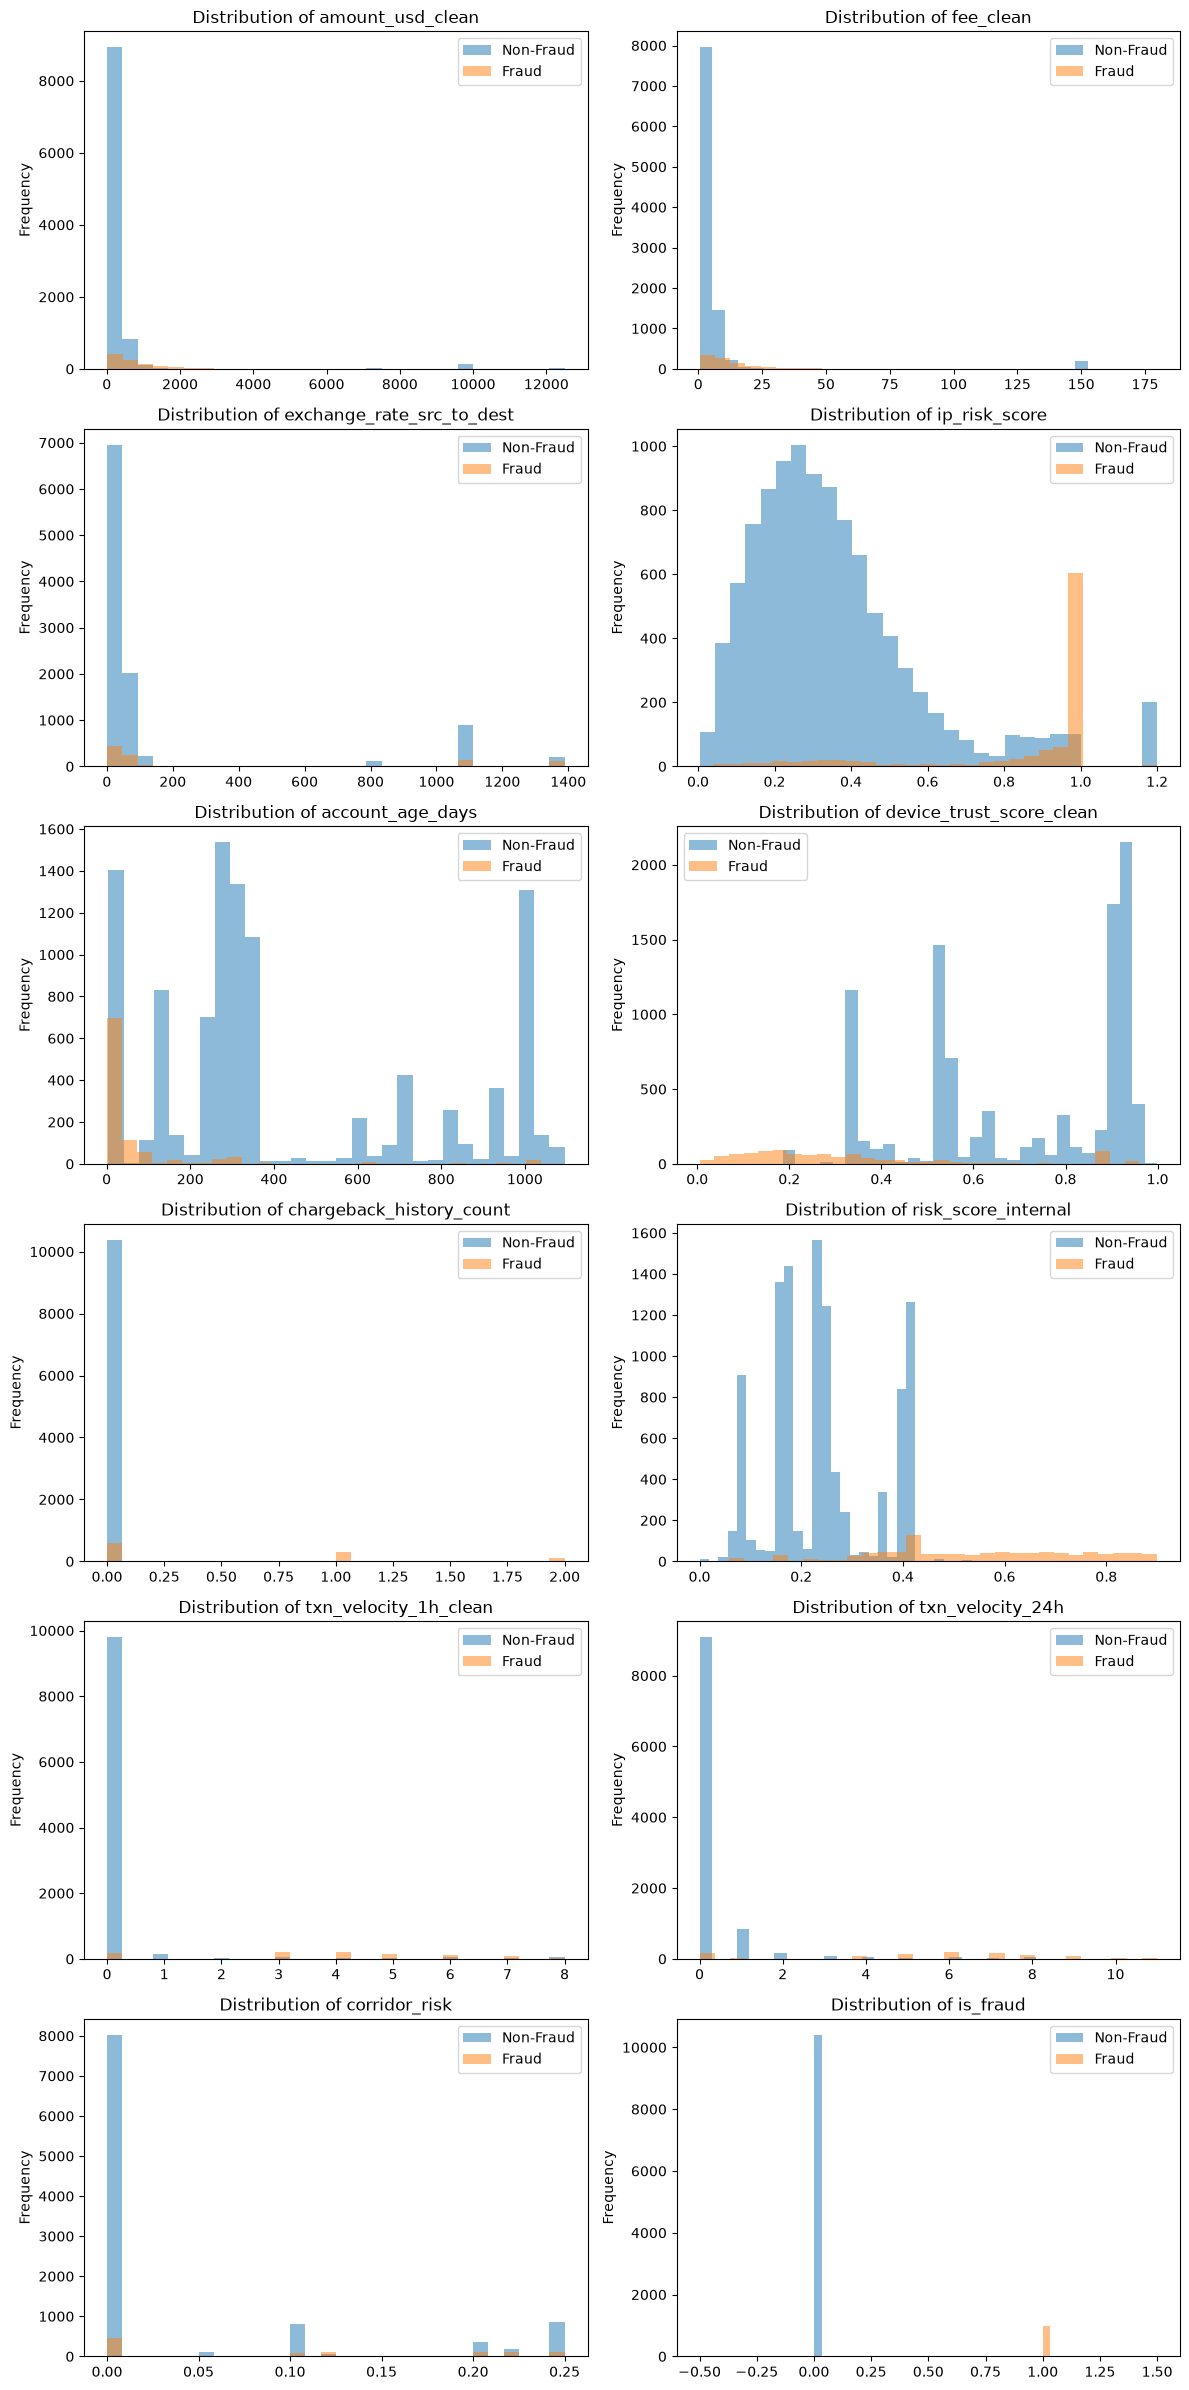

In [20796]:


import matplotlib.pyplot as plt

numeric_cols = df_clean.select_dtypes(include=['float','int']).columns

# Set up a grid of subplots (2 columns side by side)
n = len(numeric_cols)
fig, axes = plt.subplots(nrows=(n+1)//2, ncols=2, figsize=(12, 4*((n+1)//2)))

axes = axes.flatten()  # flatten to 1D for easy indexing

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    df_clean[df_clean['is_fraud']==0][col].plot(
        kind='hist', alpha=0.5, bins=30, label='Non-Fraud', ax=ax
    )
    df_clean[df_clean['is_fraud']==1][col].plot(
        kind='hist', alpha=0.5, bins=30, label='Fraud', ax=ax
    )
    ax.set_title(f'Distribution of {col}')
    ax.legend()

# Hide any unused subplot axes
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



In [20797]:
# Identify numeric columns in the DataFrame
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

amount_usd: 1043 outliers
fee: 1008 outliers
exchange_rate_src_to_dest: 1474 outliers
ip_risk_score: 1145 outliers
account_age_days: 0 outliers
device_trust_score: 0 outliers
chargeback_history_count: 442 outliers
risk_score_internal: 234 outliers
txn_velocity_1h: 1226 outliers
txn_velocity_24h: 2152 outliers
corridor_risk: 1736 outliers
is_fraud: 997 outliers
amount_usd_clean: 1043 outliers
fee_clean: 1008 outliers
device_trust_score_clean: 0 outliers
txn_velocity_1h_clean: 1226 outliers
hour: 0 outliers
is_night_transaction: 0 outliers


An outlier analysis was conducted to identify unusually high or low values in the dataset. The results show that several variables contain outliers, particularly customer maximum transaction amount, transaction velocity over the last 24 hours, corridor risk, and exchange rate, indicating the presence of transactions that differ substantially from the majority of observations. In contrast, variables such as account age, transaction number, IP frequency, and high-risk country did not contain any outliers. This analysis helps to identify extreme observations that may represent abnormal transaction behavior, data anomalies, or potential indicators of fraudulent activity and provides valuable insight before proceeding with further analysis or model development.

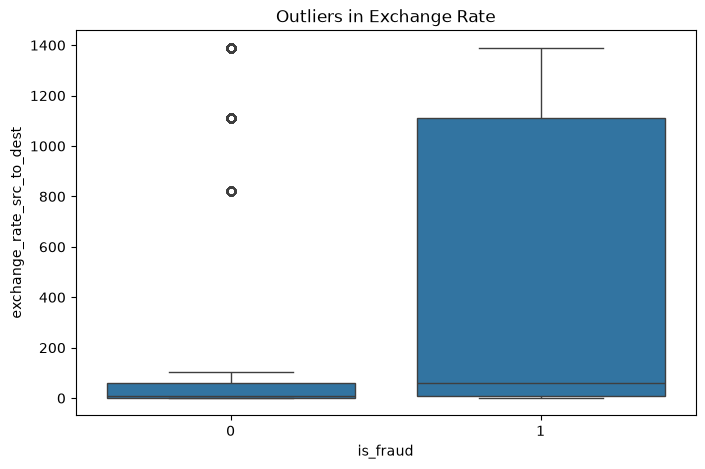

In [20798]:
# Visualize outliers in the 'exchange_rate_src_to_dest' column using a boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['is_fraud'], y=df['exchange_rate_src_to_dest'])
plt.title("Outliers in Exchange Rate")
plt.show()

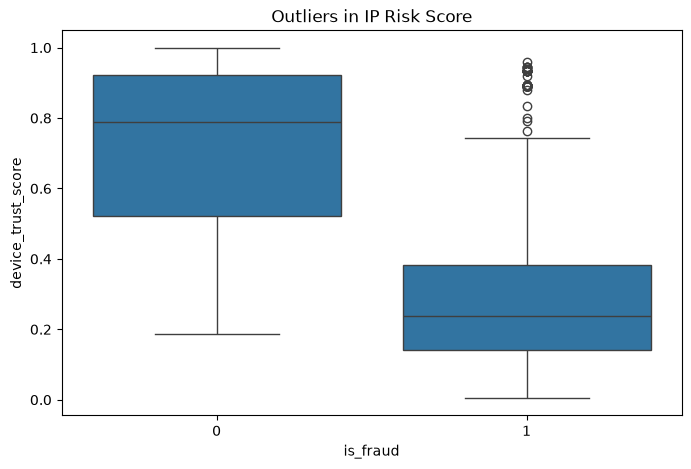

In [20799]:
# Visualize outliers in the 'device_trust_score' column using a boxplot     
plt.figure(figsize=(8,5))
sns.boxplot(x=df['is_fraud'], y=df['device_trust_score'])
plt.title("Outliers in IP Risk Score")
plt.show()

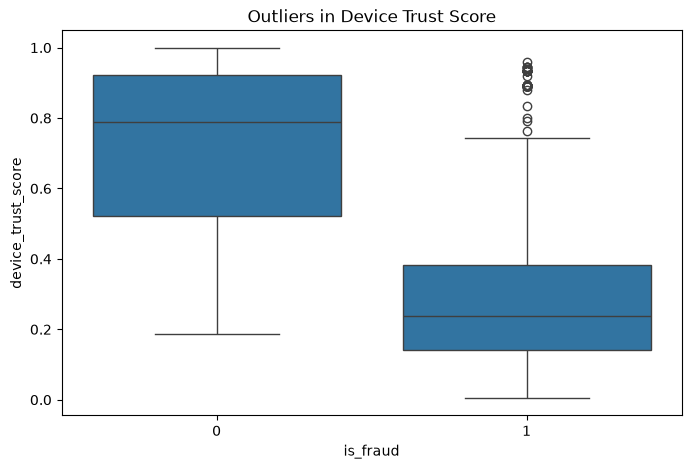

In [20800]:
# Visualize outliers in the 'device_trust_score' column using a boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['is_fraud'], y=df['device_trust_score'])
plt.title("Outliers in Device Trust Score")
plt.show()

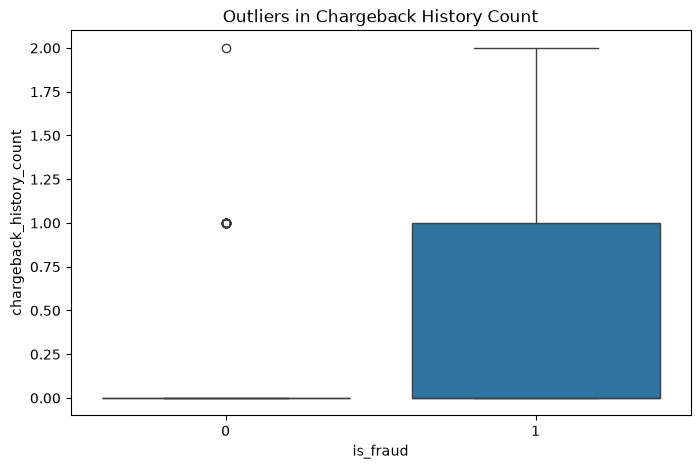

In [20801]:
# Visualize outliers in the 'chargeback_history_count' column using a boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['is_fraud'], y=df['chargeback_history_count'])
plt.title("Outliers in Chargeback History Count")
plt.show()

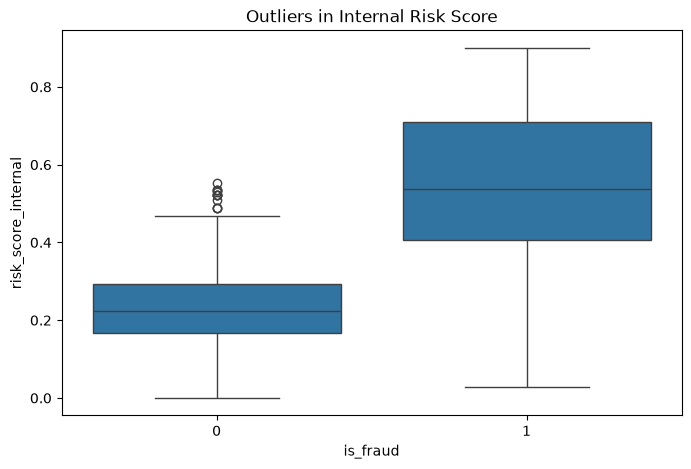

In [20802]:
# Visualize outliers in the 'risk_score_internal' column using a boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['is_fraud'], y=df['risk_score_internal'])
plt.title("Outliers in Internal Risk Score")
plt.show()

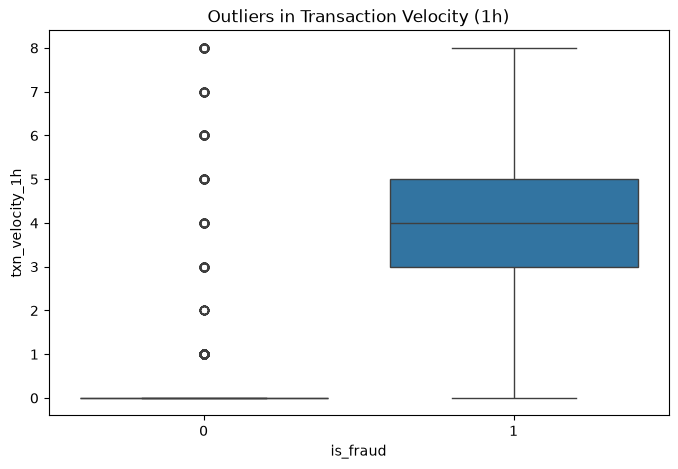

In [20803]:
# Visualize outliers in the 'txn_velocity_1h' column using a boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['is_fraud'], y=df['txn_velocity_1h'])
plt.title("Outliers in Transaction Velocity (1h)")
plt.show()

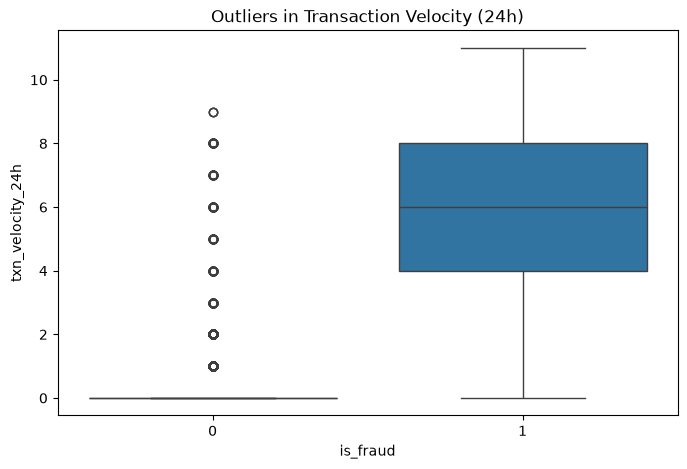

In [20804]:
# Visualize outliers in the 'txn_velocity_1h' column using a boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['is_fraud'], y=df['txn_velocity_24h'])
plt.title("Outliers in Transaction Velocity (24h)")
plt.show()

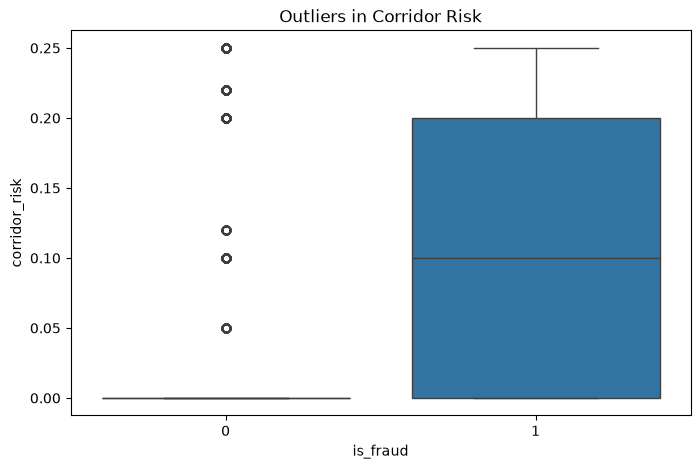

In [20805]:
# Visualize outliers in the 'corridor_risk' column using a boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['is_fraud'], y=df['corridor_risk'])
plt.title("Outliers in Corridor Risk")
plt.show()

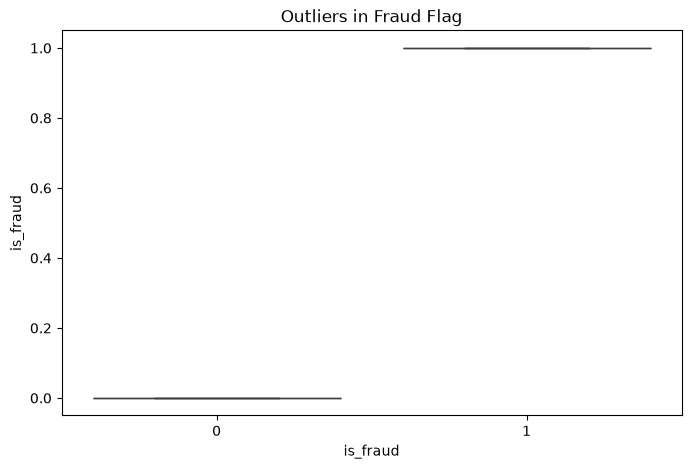

In [20806]:
# Visualize outliers in the 'is_fraud' column using a boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['is_fraud'], y=df['is_fraud'])
plt.title("Outliers in Fraud Flag")
plt.show()

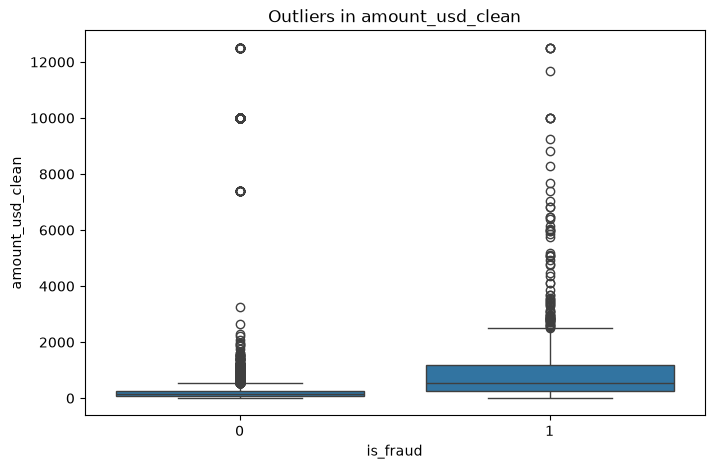

In [20807]:
# Visualize outliers in the 'is_fraud' column using a boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['is_fraud'], y=df['amount_usd_clean'])
plt.title("Outliers in amount_usd_clean")
plt.show()

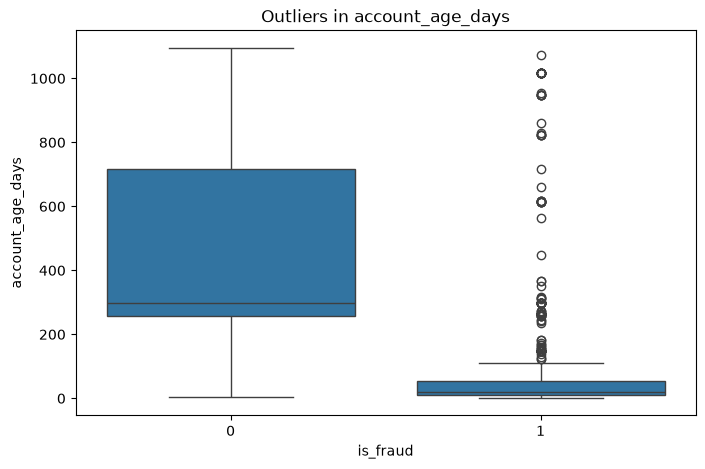

In [20808]:
# Visualize outliers in the 'is_fraud' column using a boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['is_fraud'], y=df['account_age_days'])
plt.title("Outliers in account_age_days")
plt.show()

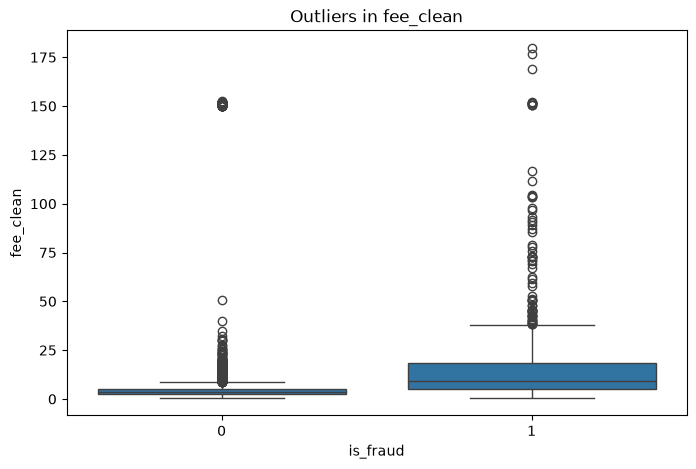

In [20809]:
# Visualize outliers in the 'is_fraud' column using a boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['is_fraud'], y=df['fee_clean'])
plt.title("Outliers in fee_clean")
plt.show()

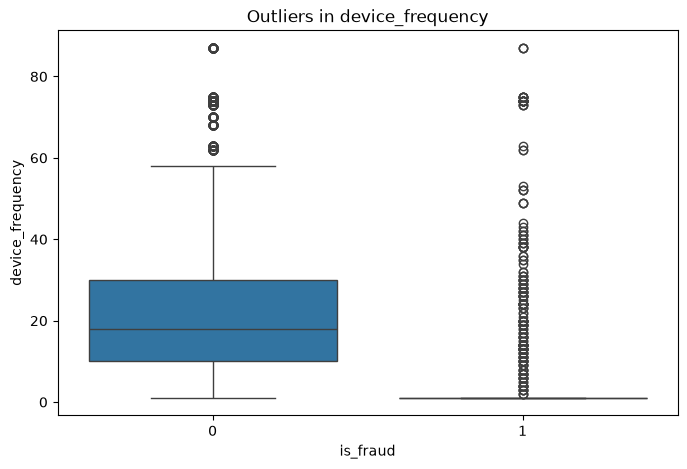

In [20810]:
# Visualize outliers in the 'is_fraud' column using a boxplot
plt.figure(figsize=(8,5))
if 'device_frequency' not in df.columns:
    if 'device_id' in df.columns and 'transaction_id' in df.columns:
        df['device_frequency'] = df.groupby('device_id')['transaction_id'].transform('count')
    elif 'device_id' in df.columns:
        df['device_frequency'] = df.groupby('device_id').cumcount()+1
    else:
        df['device_frequency'] = df.groupby('customer_id')['transaction_id'].transform('count')

sns.boxplot(x='is_fraud', y='device_frequency', data=df)
plt.title("Outliers in device_frequency")
plt.show()

In [20811]:
# Count frequency of each source currency
# Count frequency of each source currency
source_counts = df['source_currency'].value_counts(dropna=False)

print(source_counts)




source_currency
USD    8031
GBP    2139
CAD    1230
Name: count, dtype: int64


In [20813]:
source_percent = df['source_currency'].value_counts(normalize=True) * 100
print(source_percent.round(2))



source_currency
USD    70.45
GBP    18.76
CAD    10.79
Name: proportion, dtype: float64


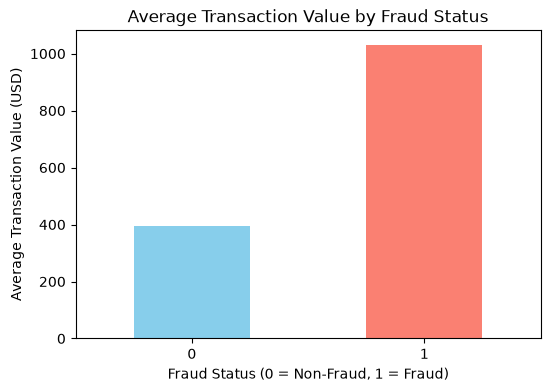

In [20821]:
import matplotlib.pyplot as plt

# Compute average transaction value by fraud status
avg_txn_value = df_clean.groupby('is_fraud')['amount_usd_clean'].mean()

# Plot bar chart
avg_txn_value.plot(kind='bar', color=['skyblue','salmon'], figsize=(6,4))
plt.title("Average Transaction Value by Fraud Status")
plt.xlabel("Fraud Status (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Average Transaction Value (USD)")
plt.xticks(rotation=0)
plt.show()


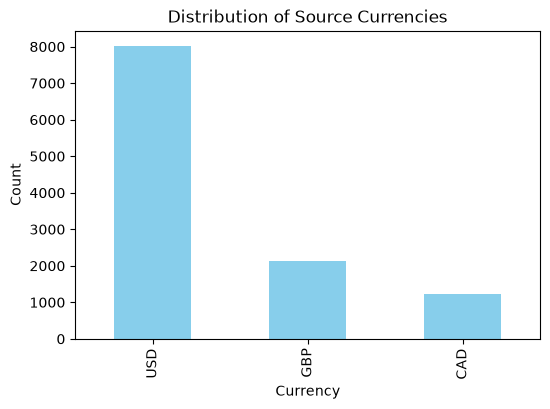

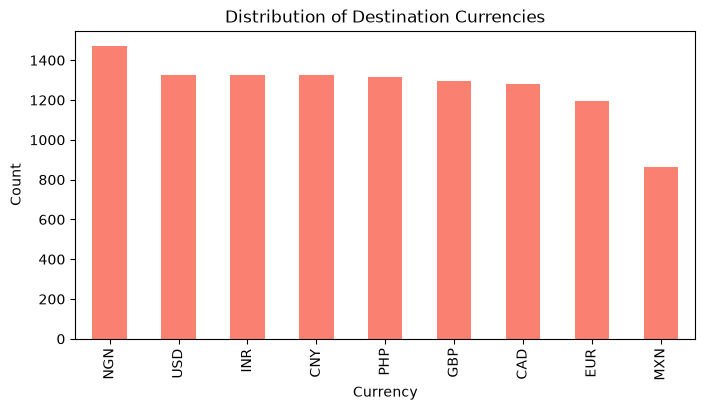

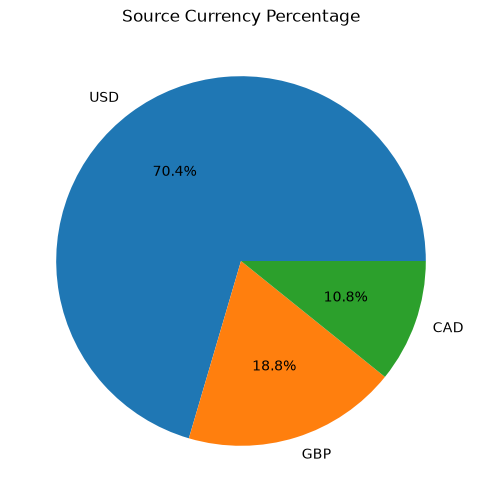

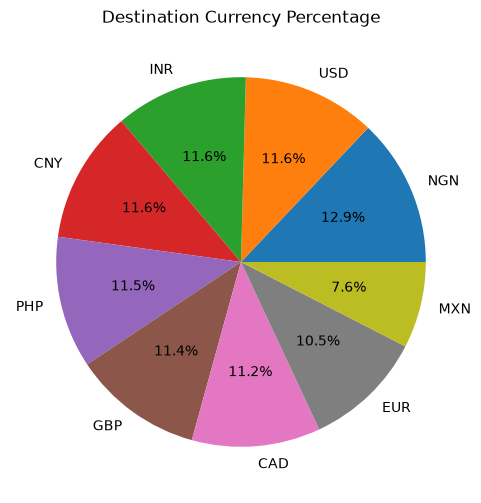

In [20826]:
# Source currency bar chart
src_series = df_clean['source_currency'] if 'source_currency' in df_clean.columns else df['source_currency']
src_series.value_counts().plot(kind='bar', color='skyblue', figsize=(6,4))
plt.title("Distribution of Source Currencies")
plt.xlabel("Currency")
plt.ylabel("Count")
plt.show()

# Destination currency bar chart
dest_series = df_clean['dest_currency'] if 'dest_currency' in df_clean.columns else df['dest_currency']
dest_series.value_counts().plot(kind='bar', color='salmon', figsize=(8,4))
plt.title("Distribution of Destination Currencies")
plt.xlabel("Currency")
plt.ylabel("Count")
plt.show()

# Pie chart for source currencies
src_series.value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title("Source Currency Percentage")
plt.ylabel("")
plt.show()

# Pie chart for destination currencies
dest_series.value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title("Destination Currency Percentage")
plt.ylabel("")
plt.show()


## Categorical Feature Distribution of Fraud Cases

In [19402]:
# Display the shape of the DataFrame (number of rows and columns)
print("\nShape")
print(df.shape)


Shape
(11400, 35)


In [19403]:
# Display the distribution of the 'is_fraud' column to understand the balance of classes
print("\nFraud Distribution")
print(df['is_fraud'].value_counts())


Fraud Distribution
is_fraud
0    10403
1      997
Name: count, dtype: int64


In [17991]:
# Display the percentage of fraudulent transactions in the dataset
print("\nFraud Percentage")
print(df['is_fraud'].value_counts(normalize=True)*100)


Fraud Percentage
is_fraud
0    91.224976
1     8.775024
Name: proportion, dtype: float64


In [17992]:
# Convert the 'timestamp' column to datetime format, handling any errors by coercing invalid values to NaT (Not a Time)
df['timestamp'] = pd.to_datetime(
    df['timestamp'],
    errors='coerce'
)

In [17993]:
# Identify rows with invalid timestamps (NaT) and display their transaction IDs and timestamps
invalid_rows = df[df['timestamp'].isna()]
print(invalid_rows[['transaction_id', 'timestamp']])

Empty DataFrame
Columns: [transaction_id, timestamp]
Index: []


In [17994]:
# Drop rows with invalid timestamps to ensure a clean dataset for analysis
df = df.dropna(subset=['timestamp'])

In [17995]:
# Display the first 10 rows of the 'timestamp' column to verify the conversion to datetime format
print(df['timestamp'].head(10))

10232   2023-12-24 15:43:45.573611+00:00
10386   2024-04-12 02:12:31.573611+00:00
11314   2025-10-15 14:02:56.573611+00:00
10543   2024-07-14 22:19:08.573611+00:00
10539   2024-07-13 09:52:36.573611+00:00
10536   2024-07-11 06:03:27.573611+00:00
11355   2025-11-03 23:47:03.573611+00:00
10651   2024-09-14 07:50:14.573611+00:00
10632   2024-09-06 11:10:48.573611+00:00
10481   2024-06-04 18:46:53.573611+00:00
Name: timestamp, dtype: datetime64[us, UTC]


In [17996]:
# Display the first 5 rows of the 'timestamp' column
print(df['timestamp'].head(5))
print(df['timestamp'].sample(5))


10232   2023-12-24 15:43:45.573611+00:00
10386   2024-04-12 02:12:31.573611+00:00
11314   2025-10-15 14:02:56.573611+00:00
10543   2024-07-14 22:19:08.573611+00:00
10539   2024-07-13 09:52:36.573611+00:00
Name: timestamp, dtype: datetime64[us, UTC]
10296   2024-02-08 07:03:41.573611+00:00
9387    2025-07-30 23:56:59.468549+00:00
3887    2023-12-06 03:23:08.468549+00:00
2879    2023-08-19 22:01:26.468549+00:00
1734    2023-04-13 23:33:33.468549+00:00
Name: timestamp, dtype: datetime64[us, UTC]


In [17997]:
# Display the data type of the 'timestamp' column to confirm it is in datetime format
print(df['timestamp'].dtype)

datetime64[us, UTC]


In [17998]:
# Extract datetime components
# Date
df['date'] = df['timestamp'].dt.date

# Time
df['time'] = df['timestamp'].dt.time

# Hour
df['hour'] = df['timestamp'].dt.hour

# Day of week (0=Monday)
df['day_of_week'] = df['timestamp'].dt.dayofweek

# Day name
df['day_name'] = df['timestamp'].dt.day_name()

# Month
df['month'] = df['timestamp'].dt.month

# Month name
df['month_name'] = df['timestamp'].dt.month_name()

# Quarter
df['quarter'] = df['timestamp'].dt.quarter

# Year
df['year'] = df['timestamp'].dt.year

# Weekend indicator
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)



In [17999]:
# Sort the DataFrame by 'customer_id' and 'timestamp' to prepare for time-based analysis
df = df.sort_values(['customer_id', 'timestamp'])



In [18000]:
# Create a new column 'transaction_number' that represents the sequential transaction number for each customer
df['transaction_number'] = (
    df.groupby('customer_id').cumcount() + 1
)


In [18001]:
# Create a new column 'transaction_number' that represents the sequential transaction number for each customer
df['transaction_number'] = (
    df.groupby('customer_id').cumcount() + 1
)


In [18002]:
# Calculate the time difference in minutes between consecutive transactions for each customer and store it in a new column 'minutes_since_last_txn'
df['minutes_since_last_txn'] = (
    df.groupby('customer_id')['timestamp']
      .diff()
      .dt.total_seconds()
      .div(60)
)


In [18003]:
# Fill missing values in the 'minutes_since_last_txn' column with 0, indicating that there was no previous transaction for those cases
df['minutes_since_last_txn'] = (
    df['minutes_since_last_txn'].fillna(0)
)


In [18004]:
# Fill missing values in the 'minutes_since_last_txn' column with 0, indicating that there was no previous transaction for those cases
df['minutes_since_last_txn'] = (
    df['minutes_since_last_txn'].fillna(0)
)


In [18005]:
# Create a new column 'device_frequency' that represents the number of transactions made from each device
df['device_frequency'] = (
    df.groupby('device_id')['device_id']
      .transform('count')
)


In [18006]:
# Create a new column 'ip_frequency' that represents the number of transactions made from each IP address
df['ip_frequency'] = (
    df.groupby('ip_address')['ip_address']
      .transform('count')
)


In [18007]:
# Create a new column 'customer_avg_amount' that represents the average transaction amount for each customer
df['customer_avg_amount'] = (
    df.groupby('customer_id')['amount_usd']
      .transform('mean')
)


In [18008]:
# Create a new column 'customer_max_amount' that represents the maximum transaction amount for each customer
df['customer_max_amount'] = (
    df.groupby('customer_id')['amount_usd']
      .transform('max')
)

In [18009]:
# Print a success message
print("New columns created successfully!")

print(df[['timestamp',
          'hour',
          'day_name',
          'month',
          'year',
          'is_weekend']].head())

New columns created successfully!
                             timestamp  hour   day_name  month  year  \
10232 2023-12-24 15:43:45.573611+00:00    15     Sunday     12  2023   
10386 2024-04-12 02:12:31.573611+00:00     2     Friday      4  2024   
11314 2025-10-15 14:02:56.573611+00:00    14  Wednesday     10  2025   
10543 2024-07-14 22:19:08.573611+00:00    22     Sunday      7  2024   
10539 2024-07-13 09:52:36.573611+00:00     9   Saturday      7  2024   

       is_weekend  
10232           1  
10386           0  
11314           0  
10543           1  
10539           1  


New features were created from the transaction timestamp to provide additional information about when each transaction occurred. These included the transaction date, time, hour, day of the week, day name, month, month name, quarter, year, and an indicator identifying whether the transaction occurred on a weekend. The dataset was then sorted by customer and transaction time to preserve the chronological order of transactions. Customer behavioural features were also generated, including the sequence number of each transaction, the time elapsed since the customer's previous transaction, the frequency of device and IP address usage, and each customer's average and maximum transaction amounts. These engineered features enrich the dataset by capturing temporal patterns and customer transaction behaviour, which can improve exploratory analysis and enhance the performance of fraud detection models.

    hour  is_fraud  Fraud Rate (%)
0      0  0.061441        6.144068
1      1  0.062053        6.205251
2      2  0.076389        7.638889
3      3  0.121032       12.103175
4      4  0.180769       18.076923
5      5  0.155870       15.587045
6      6  0.203704       20.370370
7      7  0.176724       17.672414
8      8  0.123752       12.375250
9      9  0.044944        4.494382
10    10  0.069620        6.962025
11    11  0.075221        7.522124
12    12  0.059957        5.995717
13    13  0.063694        6.369427
14    14  0.076923        7.692308
15    15  0.057732        5.773196
16    16  0.063025        6.302521
17    17  0.053691        5.369128
18    18  0.076289        7.628866
19    19  0.044231        4.423077
20    20  0.060215        6.021505
21    21  0.076577        7.657658
22    22  0.057447        5.744681
23    23  0.043651        4.365079


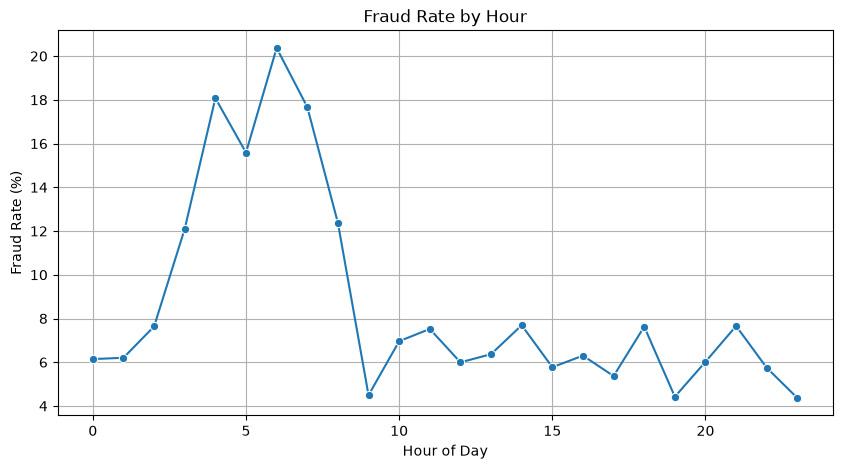

In [18010]:
# Analyze fraud rate by hour
fraud_hour = (
    df.groupby('hour')['is_fraud']
      .mean()
      .reset_index()
)

fraud_hour['Fraud Rate (%)'] = fraud_hour['is_fraud'] * 100
print(fraud_hour)

plt.figure(figsize=(10,5))
sns.lineplot(data=fraud_hour, x='hour', y='Fraud Rate (%)', marker='o')
plt.title('Fraud Rate by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate (%)')
plt.grid(True)
plt.show()

The fraud rate was calculated for each hour of the day to examine how fraudulent transactions vary over a 24-hour period. The results show the proportion and percentage of fraudulent transactions recorded during each hour, making it possible to identify periods with relatively higher or lower fraud activity. This analysis provides insight into the relationship between transaction time and fraud occurrence, helping to determine whether fraud is more likely to occur during specific hours of the day.

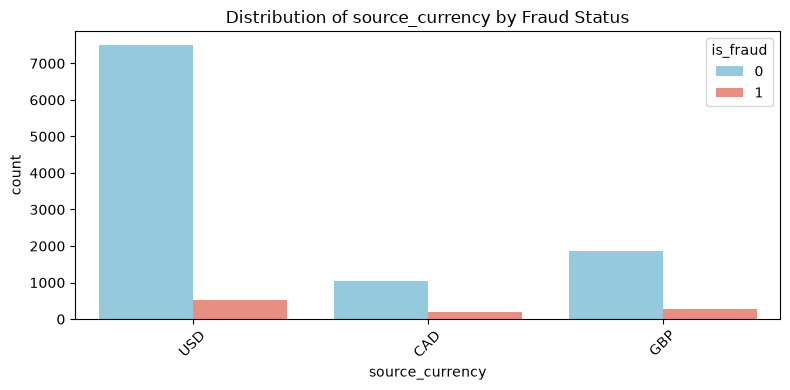

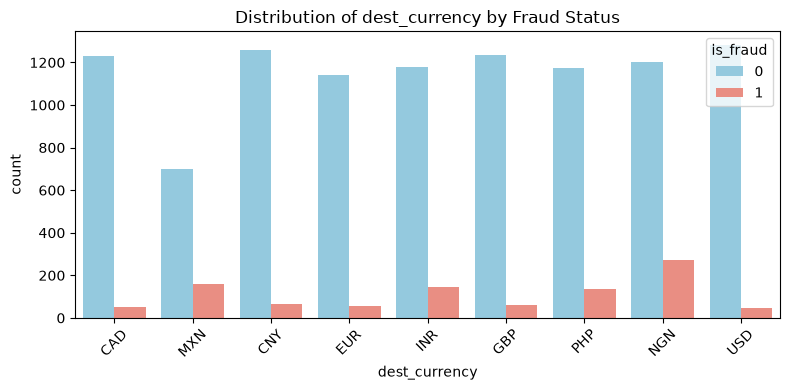

In [20830]:
# Analyze fraud rate by day of week
for col in ['source_currency','dest_currency']:
    # use df_clean when it contains the column, otherwise fall back to the original df
    data_used = df_clean if col in df_clean.columns else df
    plt.figure(figsize=(8,4))
    sns.countplot(data=data_used, x=col, hue='is_fraud', palette=['skyblue','salmon'])
    plt.title(f"Distribution of {col} by Fraud Status")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    day_name  is_fraud  Fraud Rate (%)
1     Monday  0.081769        8.176863
5    Tuesday  0.097411        9.741060
6  Wednesday  0.081285        8.128544
4   Thursday  0.094294        9.429429
0     Friday  0.084951        8.495146
2   Saturday  0.089263        8.926342
3     Sunday  0.085038        8.503836


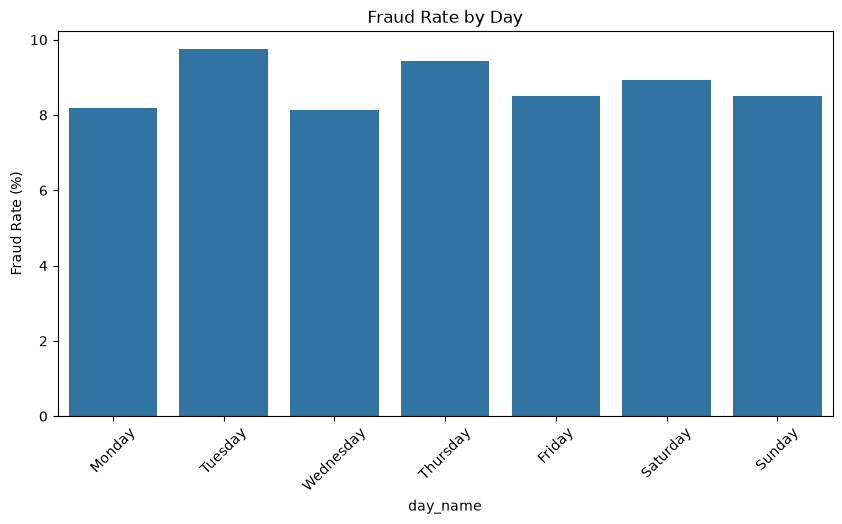

In [20848]:
#can we put color on this like above code 

# Analyze fraud rate by day of the week
fraud_day = (
    df.groupby('day_name')['is_fraud']
      .mean()
      .reset_index()
)

order = ['Monday','Tuesday','Wednesday','Thursday',
         'Friday','Saturday','Sunday']

fraud_day['day_name'] = pd.Categorical(
    fraud_day['day_name'],
    categories=order,
    ordered=True
)

# Sort the DataFrame by 'day_name' to ensure the days are in the correct order for visualization

fraud_day = fraud_day.sort_values('day_name')
fraud_day['Fraud Rate (%)'] = fraud_day['is_fraud']*100


print(fraud_day)

plt.figure(figsize=(10,5))
sns.barplot(data=fraud_day,x='day_name',y='Fraud Rate (%)')
plt.xticks(rotation=45)
plt.title("Fraud Rate by Day")
plt.show()

The fraud rate was analyzed for each day of the week to determine whether fraudulent transactions were more common on certain days. The analysis calculated the proportion and percentage of fraudulent transactions for each weekday, allowing for a comparison of fraud patterns across the week. This provides insight into whether the likelihood of fraud changes depending on the day on which a transaction occurs.

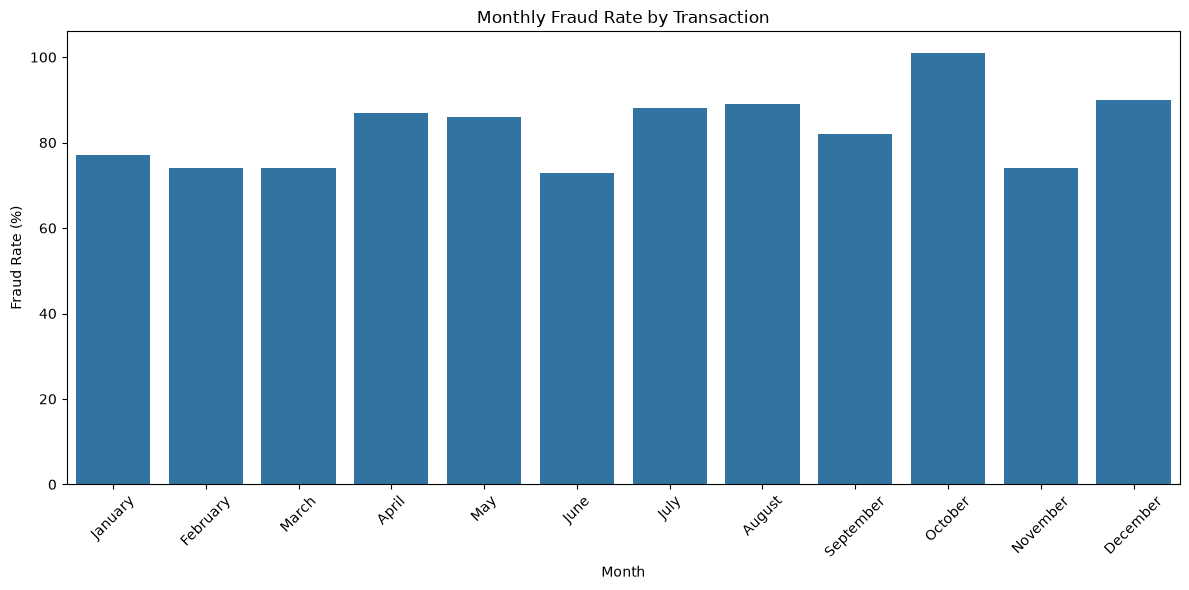

In [20942]:

# Use df_clean if it contains the month column, otherwise fall back to df
source = df_clean if 'transaction_monthname' in df_clean.columns else df

# Fraud counts by transaction month
fraud_counts = (
    source.groupby('transaction_monthname', dropna=False)['is_fraud']
          .sum()   # sum of fraud flags = number of fraud transactions
          .reset_index()
)

# Ensure months are ordered chronologically
order = ['January','February','March','April','May','June',
         'July','August','September','October','November','December']

fraud_counts['transaction_monthname'] = pd.Categorical(
    fraud_counts['transaction_monthname'],
    categories=order,
    ordered=True
)

fraud_counts = fraud_counts.sort_values('transaction_monthname')
fraud_counts.rename(columns={'is_fraud':'Fraud Count'}, inplace=True)

plt.figure(figsize=(12,6))
sns.barplot(data=fraud_counts, x='transaction_monthname', y='Fraud Count')
plt.xticks(rotation=45)
plt.title("Monthly Fraud Rate by Transaction")
plt.ylabel("Fraud Rate (%)")
plt.xlabel("Month")
plt.tight_layout()
plt.show()


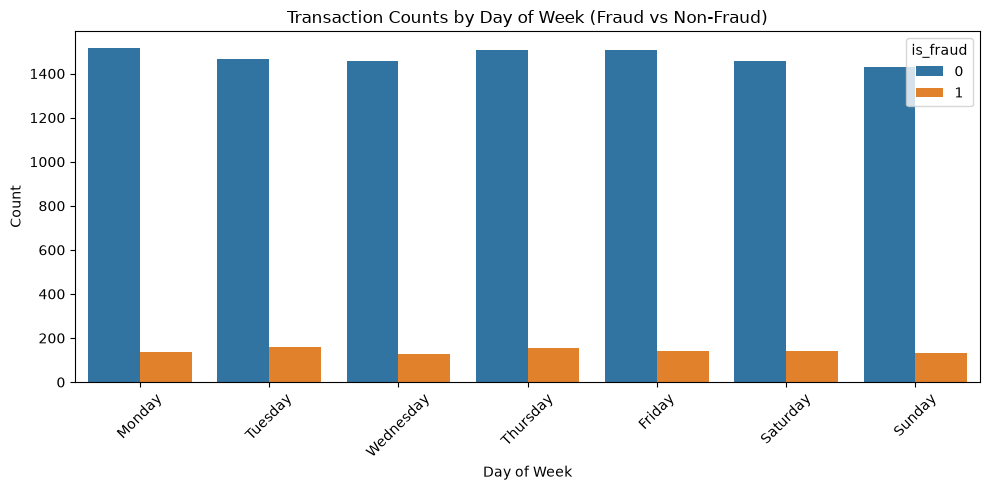

In [20859]:


# Make sure day_name exists
if 'day_name' not in df_clean.columns:
    import matplotlib.pyplot as plt

    # Make sure day_name exists
    if 'day_name' not in df_clean.columns:
        if 'day_name' in df.columns:
            df_clean['day_name'] = df['day_name']
        elif 'timestamp' in df.columns:
            df_clean['day_name'] = pd.to_datetime(df['timestamp'], errors='coerce').dt.day_name()
        else:
            raise KeyError("timestamp column missing in both df_clean and df")

    plt.figure(figsize=(10,5))
    sns.countplot(
        data=df_clean,
        x='day_name',
        hue='is_fraud'
    )
    plt.title("Transaction Counts by Day of Week (Fraud vs Non-Fraud)")
    plt.xticks(rotation=45)
    plt.ylabel("Count")
    plt.xlabel("Day of Week")
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(10,5))
sns.countplot(
    data=df_clean,
    x='day_name',
    hue='is_fraud'
)
plt.title("Transaction Counts by Day of Week (Fraud vs Non-Fraud)")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.xlabel("Day of Week")
plt.tight_layout()
plt.show()


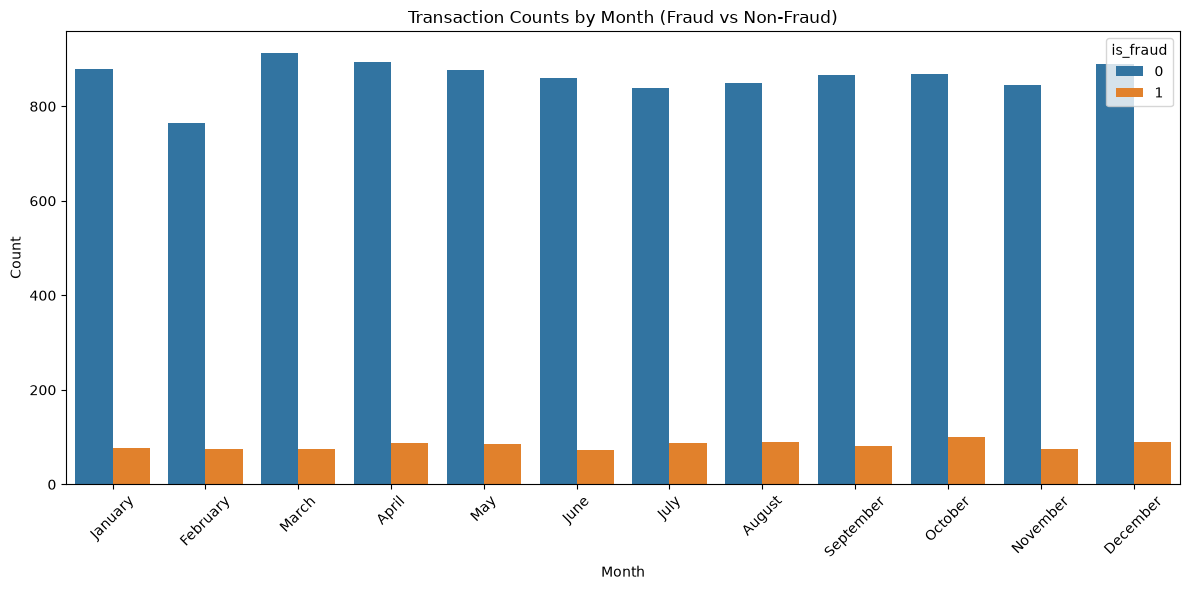

In [20861]:
# Make sure transaction_monthname exists
if 'transaction_monthname' not in df_clean.columns:
    df_clean['transaction_monthname'] = pd.to_datetime(df_clean['timestamp'], errors='coerce').dt.month_name()

order = ['January','February','March','April','May','June',
         'July','August','September','October','November','December']

plt.figure(figsize=(12,6))
sns.countplot(
    data=df_clean,
    x='transaction_monthname',
    hue='is_fraud',
    order=order
)
plt.title("Transaction Counts by Month (Fraud vs Non-Fraud)")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.xlabel("Month")
plt.tight_layout()
plt.show()


is_fraud                   0          1
location_mismatch                      
False              96.439045   3.560955
True               64.524838  35.475162


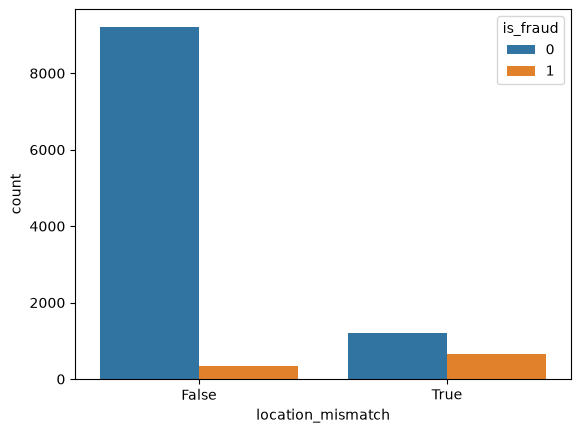

In [20863]:
# Analyze fraud rate by location mismatch
fraud_location = pd.crosstab(
    df['location_mismatch'],
    df['is_fraud'],
    normalize='index'
)*100

print(fraud_location)

sns.countplot(
    data=df,
    x='location_mismatch',
    hue='is_fraud'
)
plt.show()

is_fraud            0          1
new_device                      
False       95.162735   4.837265
True        62.232077  37.767923


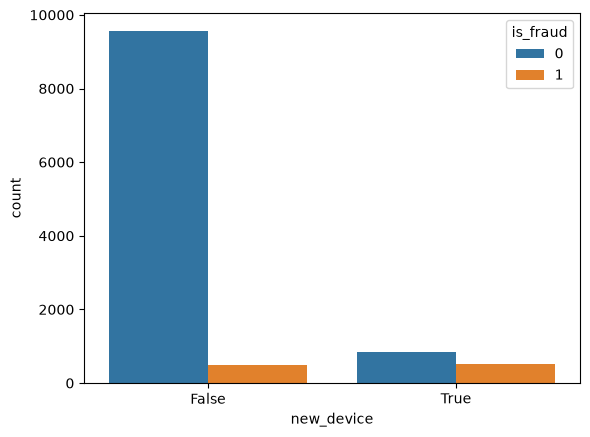

In [20864]:
# Analyze fraud rate by new device
fraud_device = pd.crosstab(
    df['new_device'],
    df['is_fraud'],
    normalize='index'
)*100

print(fraud_device)

sns.countplot(
    data=df,
    x='new_device',
    hue='is_fraud'
)
plt.show()

The fraud rate was analyzed according to the customers' home country to determine whether the likelihood of fraudulent transactions differs across countries. The analysis calculated the proportion and percentage of fraudulent transactions for each country, allowing for comparisons of fraud occurrence among different customer locations.

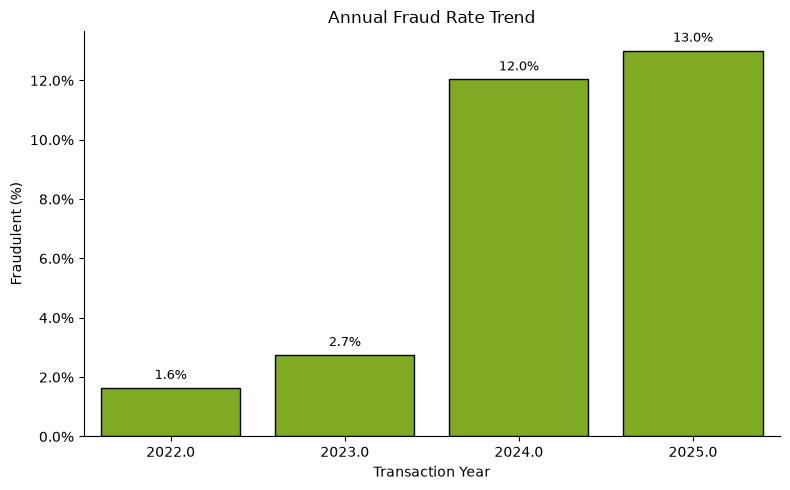

In [20870]:

import matplotlib.ticker as mtick
# Calculate annual fraud rate
if 'transaction_year' not in df_clean.columns:
    if 'year' in df_clean.columns:
        df_clean['transaction_year'] = df_clean['year']
    else:
        if 'timestamp' in df_clean.columns:
            df_clean['transaction_year'] = pd.to_datetime(
            df_clean['timestamp'],
            errors='coerce'
            ).dt.year
        elif 'timestamp' in df.columns:
            df_clean['transaction_year'] = pd.to_datetime(
            df['timestamp'],
            errors='coerce'
            ).dt.year
        else:
            raise KeyError("timestamp column missing in both df_clean and df")

fraud_trend = (
    df_clean
    .groupby("transaction_year")["is_fraud"]
    .mean()
    .reset_index(name="fraud_rate")
)

# Convert to percentage
fraud_trend["fraud_rate_pct"] = fraud_trend["fraud_rate"] * 100

plt.figure(figsize=(8,5))
sns.barplot(
    data=fraud_trend,
    x="transaction_year",
    y="fraud_rate_pct",
    color="#89BF0E",   # consistent custom color
    edgecolor="black"  # adds outline for clarity
)

plt.title("Annual Fraud Rate Trend")
plt.xlabel("Transaction Year")
plt.ylabel("Fraudulent (%)")

# Format y-axis as percentage
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())

# Annotate bars with values
for index, row in fraud_trend.iterrows():
    plt.text(
        index, row["fraud_rate_pct"] + 0.2,
        f"{row['fraud_rate_pct']:.1f}%",
        ha='center', va='bottom', fontsize=9
    )

sns.despine()
plt.tight_layout()
plt.show()


Fraud: 16,004.38 (19.04%)
Non-Fraud: 68,033.99 (80.96%)


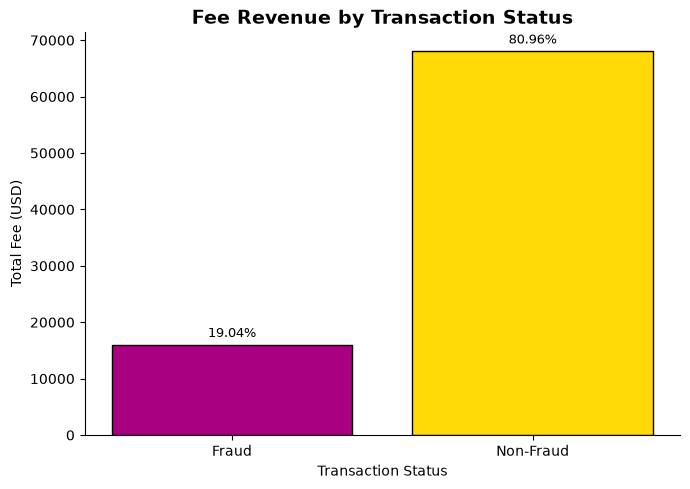

In [20873]:
import seaborn as sns
import matplotlib.pyplot as plt

# Total fee summary by transaction status
source_df = df_clean if 'is_fraud' in df_clean.columns else df

fee_summary = (
    source_df
    .assign(fraud_status=source_df['is_fraud'].map({0: "Non-Fraud", 1: "Fraud"}))
    .groupby("fraud_status")["fee_clean"]
    .sum()
    .reset_index()
)

fee_summary.columns = ["fraud_status", "total_fee"]

# Calculate percentage contribution
total = fee_summary["total_fee"].sum()
fee_summary["percentage"] = (fee_summary["total_fee"] / total * 100).round(2)

# Print results
for _, row in fee_summary.iterrows():
    print(f"{row['fraud_status']}: {row['total_fee']:,.2f} ({row['percentage']}%)")

# Visualization
plt.figure(figsize=(7,5))
colors = ["#A80081", "#ffda07"]

plt.bar(
    fee_summary["fraud_status"],
    fee_summary["total_fee"],
    color=colors,
    edgecolor="black"
)

plt.title("Fee Revenue by Transaction Status", fontsize=14, fontweight="bold")
plt.xlabel("Transaction Status")
plt.ylabel("Total Fee (USD)")
plt.xticks(rotation=0)

# Add percentage labels on top of bars
for i, row in fee_summary.iterrows():
    plt.text(
        i, row["total_fee"] + (total * 0.01),  # slight offset above bar
        f"{row['percentage']}%",
        ha='center', va='bottom', fontsize=9
    )

sns.despine()
plt.tight_layout()
plt.show()


In [20877]:
# Analyze fraud rate by month
# Remove leading/trailing spaces
df['channel'] = df['channel'].str.strip()

# Convert to lowercase
df['channel'] = df['channel'].str.lower()

# Correct spelling mistakes and inconsistent values
df['channel'] = df['channel'].replace({
    'weeb': 'web',
    'mobille': 'mobile'
})

# Check the cleaned values
print(df['channel'].value_counts())

channel
mobile     6521
web        3821
atm        1021
unknown      37
Name: count, dtype: int64


   channel  is_fraud  Fraud Rate (%)
0      web  0.160953       16.095263
1      atm  0.079334        7.933399
2   mobile  0.046005        4.600521
3  unknown  0.027027        2.702703


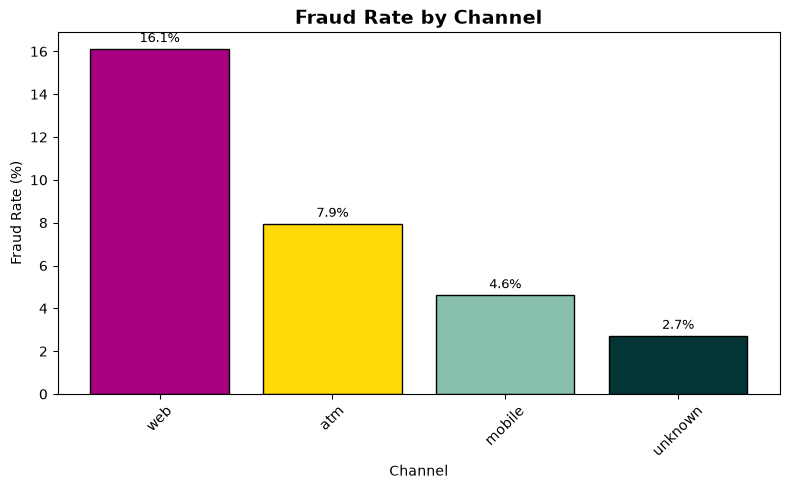

In [20896]:
# Calculate fraud rate by channel
fraud_channel = (
    df.groupby('channel')['is_fraud']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

fraud_channel['Fraud Rate (%)'] = fraud_channel['is_fraud'] * 100

print(fraud_channel)

# Define exactly 4 colors (one per channel)
colors = ["#A80081", "#ffda07", "#89BFAE", "#033536"]

plt.figure(figsize=(8,5))
plt.bar(
    fraud_channel["channel"],
    fraud_channel["Fraud Rate (%)"],
    color=colors,
    edgecolor="black"
)

plt.title("Fraud Rate by Channel", fontsize=14, fontweight="bold")
plt.xlabel("Channel")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)

# Annotate bars with values
for index, row in fraud_channel.iterrows():
    plt.text(
        index, row["Fraud Rate (%)"] + 0.2,
        f"{row['Fraud Rate (%)']:.1f}%",
        ha='center', va='bottom', fontsize=9
    )

plt.tight_layout()
plt.show()


The fraud rate was analyzed across the different transaction channels to examine whether the method used to perform a transaction is associated with fraudulent activity. The analysis calculated the proportion and percentage of fraudulent transactions for each channel, enabling a comparison of fraud occurrence across web, ATM, mobile, and other transaction methods.

In [20889]:
# Remove leading and trailing spaces
df['home_country'] = df['home_country'].str.strip()

# Convert all values to uppercase
df['home_country'] = df['home_country'].str.upper()

# Correct any spelling mistakes (if they exist)
df['home_country'] = df['home_country'].replace({
    'UNKNOWN': 'UNKNOWN',
    'UK': 'UK',
    'US': 'US',
    'CA': 'CA'
})

# Check the cleaned values
print(df['home_country'].value_counts())

home_country
US         8008
UK         2132
CA         1228
UNKNOWN      32
Name: count, dtype: int64


  home_country  is_fraud  Fraud Rate (%)
0      UNKNOWN  0.031250        3.125000
1           US  0.066059        6.605894
2           UK  0.132270       13.227017
3           CA  0.150651       15.065147


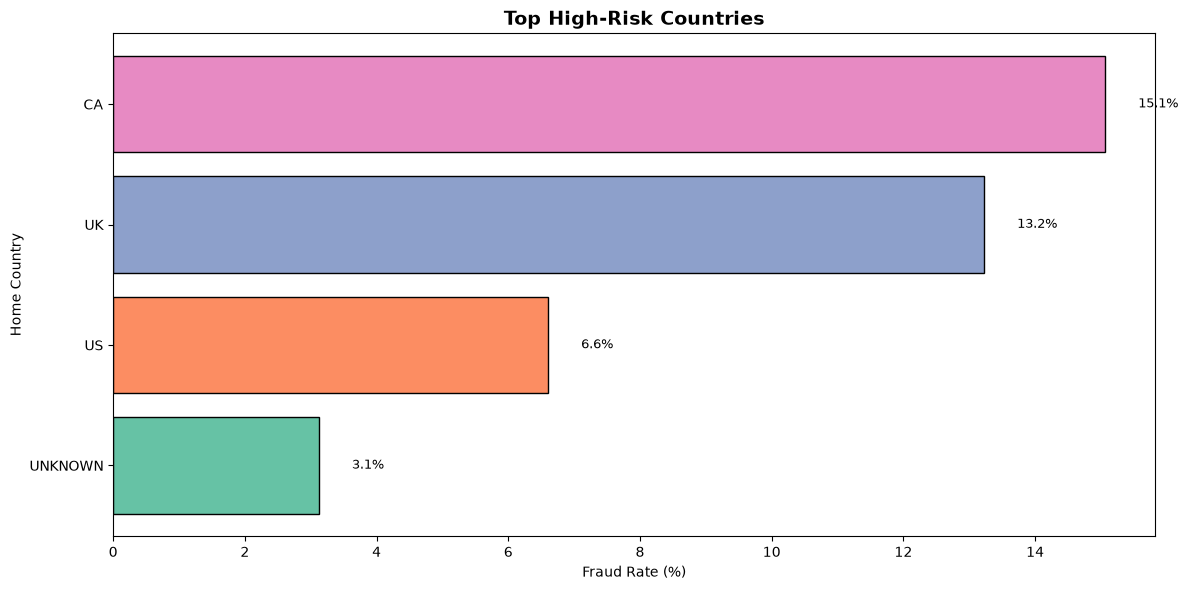

In [20901]:

# Fraud rate by home country
fraud_country = (
    df.groupby('home_country')['is_fraud']
      .mean()
      .sort_values(ascending=True)
      .reset_index()
)

fraud_country['Fraud Rate (%)'] = fraud_country['is_fraud'] * 100

print(fraud_country.head(15))

# Define 15 distinct colors (or cycle through a palette)
colors = sns.color_palette("Set2", 15)

plt.figure(figsize=(12,6))
plt.barh(
    fraud_country.head(15)['home_country'],
    fraud_country.head(15)['Fraud Rate (%)'],
    color=colors,
    edgecolor="black"
)

plt.title("Top High-Risk Countries", fontsize=14, fontweight="bold")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Home Country")

# Annotate bars with values
for index, row in fraud_country.head(15).iterrows():
    plt.text(
        row['Fraud Rate (%)'] + 0.5, index,
        f"{row['Fraud Rate (%)']:.1f}%",
        va='center', fontsize=9
    )

plt.tight_layout()
plt.show()


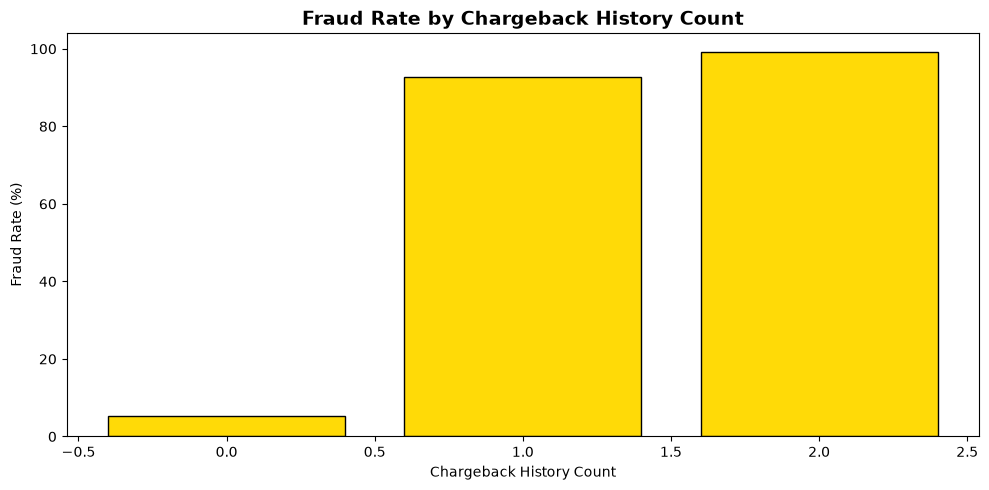

In [20904]:
# Analyze fraud rate by chargeback history count
fraud_chargeback = (
    df.groupby('chargeback_history_count')['is_fraud']
      .mean()
      .reset_index()
)
fraud_chargeback['Fraud Rate (%)'] = fraud_chargeback['is_fraud'] * 100

colors = ["#ffda07"] * len(fraud_chargeback)

plt.figure(figsize=(10,5))
plt.bar(
    fraud_chargeback['chargeback_history_count'],
    fraud_chargeback['Fraud Rate (%)'],
    color=colors,
    edgecolor="black"
)
plt.title("Fraud Rate by Chargeback History Count", fontsize=14, fontweight="bold")
plt.xlabel("Chargeback History Count")
plt.ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.show()


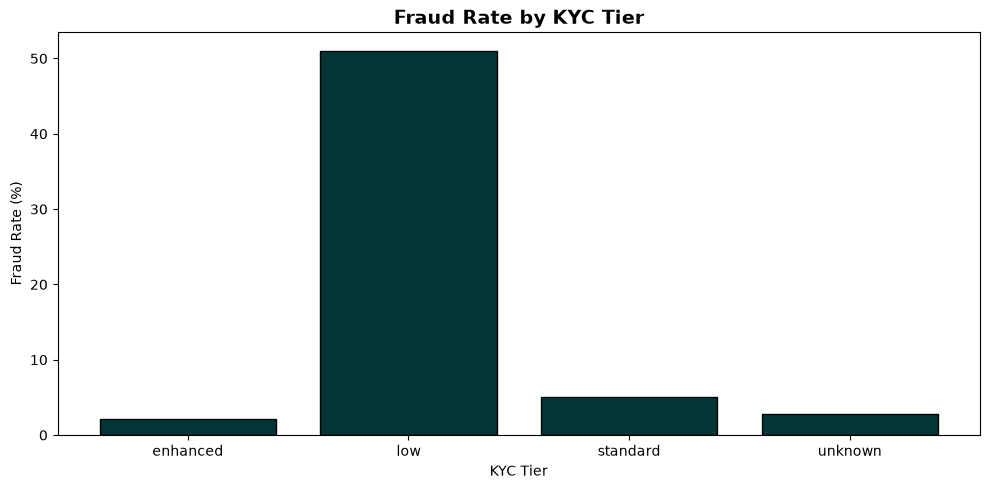

In [20914]:
df['kyc_tier_clean'] = (
    df['kyc_tier']
      .astype(str)
      .str.strip()
      .str.lower()
      .replace({
          'standrd': 'standard',
          'enhancd': 'enhanced',
          'nan': 'unknown',
          '': 'unknown'
      })
)

fraud_kyc = (
    df.groupby('kyc_tier_clean')['is_fraud']
      .mean()
      .reset_index()
)

fraud_kyc['Fraud Rate (%)'] = fraud_kyc['is_fraud'] * 100

colors = ["#033536"] * len(fraud_kyc)

plt.figure(figsize=(10,5))
plt.bar(
    fraud_kyc['kyc_tier_clean'],
    fraud_kyc['Fraud Rate (%)'],
    color=colors,
    edgecolor="black"
)
plt.title("Fraud Rate by KYC Tier", fontsize=14, fontweight="bold")
plt.xlabel("KYC Tier")
plt.ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.show()


In [20926]:

# Ensure timestamp is datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df.dropna(subset=['timestamp'])

# Sort by customer and timestamp
df = df.sort_values(['customer_id', 'timestamp'])

# Function to count transactions in the last 24h
def _count_last_24h(group):
    counts = (
        group.set_index('timestamp')['transaction_id']
             .rolling('1D')   # ✅ use uppercase 'D' for daily window
             .count()
    )
    counts.index = group.index
    return counts

# Apply per customer
df['transactions_last_24h'] = (
    df.groupby('customer_id', group_keys=False)
      .apply(_count_last_24h)
)

# Preview
print(df[['customer_id', 'timestamp', 'transactions_last_24h']].head())


                                customer_id                        timestamp  \
10232  0006f893-10a8-4235-831b-fcae1e3f0140 2023-12-24 15:43:45.573611+00:00   
10386  00147b79-11ed-4f8f-a3af-651778b78dd3 2024-04-12 02:12:31.573611+00:00   
11314  00668d83-6f9f-4401-9a0f-04f94140abb6 2025-10-15 14:02:56.573611+00:00   
10543  00957a15-945f-4bfb-b5fc-d867cbaee95d 2024-07-14 22:19:08.573611+00:00   
10539  00ab675d-a6ea-4d6e-bcdf-79027ce4f944 2024-07-13 09:52:36.573611+00:00   

       transactions_last_24h  
10232                    1.0  
10386                    1.0  
11314                    1.0  
10543                    1.0  
10539                    1.0  


A correlation analysis was performed on the numerical variables in the dataset to examine the strength and direction of the relationships between them. The resulting correlation matrix was visualized using a heatmap, where different colors represent positive, negative, or weak correlations between pairs of variables. This analysis helps to identify variables that are highly related, detect potential multicollinearity, and understand how different numerical features are associated with one another before conducting further statistical analysis or developing fraud detection models.

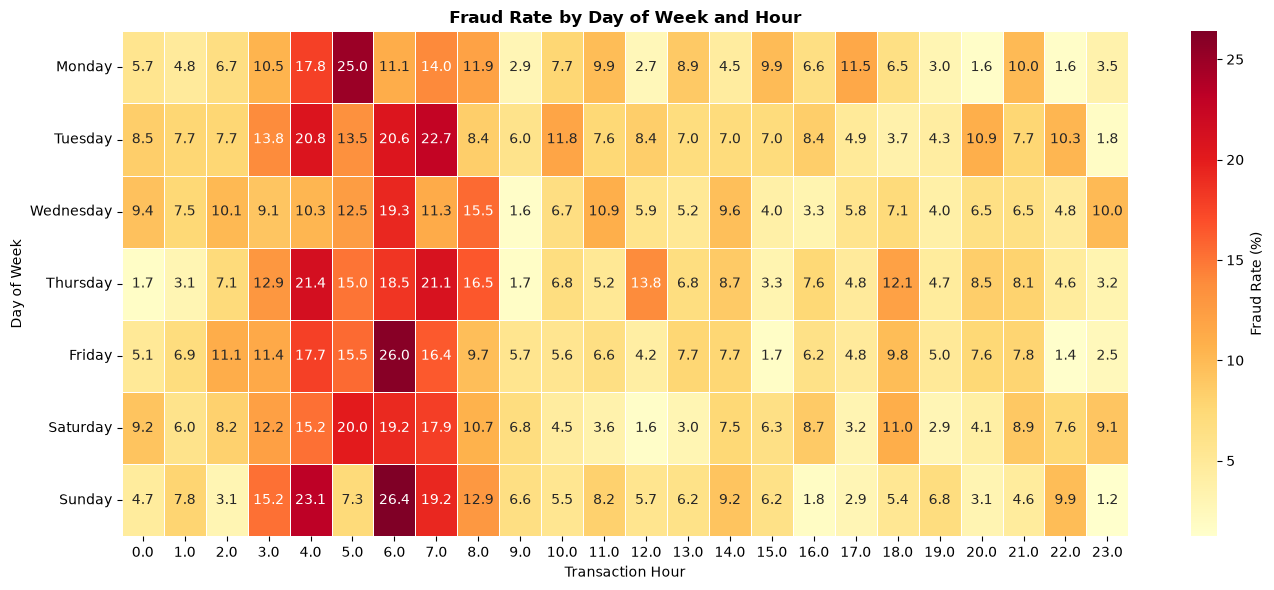

In [20927]:

# Ensure proper weekday order
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

# Create transaction_day_of_week from day_name if it doesn't exist
if 'transaction_day_of_week' not in df_clean.columns:
    df_clean['transaction_day_of_week'] = df_clean['day_name'] if 'day_name' in df_clean.columns else df['day_name']

df_clean["transaction_day_of_week"] = pd.Categorical(
    df_clean["transaction_day_of_week"],
    categories=day_order,
    ordered=True
)

# Create transaction_hour from hour if it doesn't exist
if 'transaction_hour' not in df_clean.columns:
    df_clean['transaction_hour'] = df_clean['hour'] if 'hour' in df_clean.columns else df['hour']

# Aggregate fraud rate by day and hour
heatmap_data = (
    df_clean
    .groupby(["transaction_day_of_week", "transaction_hour"])
    .agg(
        total_transactions=("is_fraud", "size"),
        fraud_transactions=("is_fraud", "sum"),
        fraud_rate=("is_fraud", "mean")
    )
    .reset_index()
)

# Convert to percentage
heatmap_data["fraud_rate_pct"] = (heatmap_data["fraud_rate"] * 100).round(2)

# Pivot for heatmap
fraud_heatmap = heatmap_data.pivot(
    index="transaction_day_of_week",
    columns="transaction_hour",
    values="fraud_rate_pct"
)

plt.figure(figsize=(14,6))
sns.heatmap(
    fraud_heatmap,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",        
    linewidths=0.5,
    cbar_kws={"label": "Fraud Rate (%)"}
)

plt.title("Fraud Rate by Day of Week and Hour", fontsize=12, fontweight="bold")
plt.xlabel("Transaction Hour")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()

# Fraud Trends by Day of the Week and Hour

In [ ]:
# Create a new column 'minutes_since_last_txn' that represents the time elapsed since the last transaction for each customer
df['minutes_since_last_txn'] = (
    df.groupby('customer_id')['timestamp']
      .diff()
      .dt.total_seconds()/60
)

df['minutes_since_last_txn'] = (
    df['minutes_since_last_txn']
      .fillna(0)
)

print(df[['customer_id',
          'minutes_since_last_txn']].head())

                                customer_id  minutes_since_last_txn
10232  0006f893-10a8-4235-831b-fcae1e3f0140                     0.0
10386  00147b79-11ed-4f8f-a3af-651778b78dd3                     0.0
11314  00668d83-6f9f-4401-9a0f-04f94140abb6                     0.0
10543  00957a15-945f-4bfb-b5fc-d867cbaee95d                     0.0
10539  00ab675d-a6ea-4d6e-bcdf-79027ce4f944                     0.0


In [ ]:
# Create a new column 'device_frequency' that represents the number of transactions made from each device
df['device_frequency'] = (
    df.groupby('device_id')['device_id']
      .transform('count')
)

print(df[['device_id',
          'device_frequency']].head())

                                  device_id  device_frequency
10232  609547e5-d0f9-4a82-bbda-29a503788d0b                 1
10386  1fe01c85-189b-4c49-a0c9-0e8f98fe1d80                 1
11314  113f3ae6-3670-4594-a672-0eec0a44c357                 1
10543  59639db6-5600-4607-8f55-9b09db5b7f8f                 1
10539  76cd2a3b-3659-4f2c-b1c9-22717bebec13                 1


In [ ]:
# Identify the top 10 devices by transaction frequency
top_devices = (
    df.groupby('device_id')
      .size()
      .sort_values(ascending=False)
      .head(10)
)

print(top_devices)

device_id
e70db499-19e1-4927-b04f-3ebfcf62e33c    87
917faeeb-252b-4379-8ba3-8c4bae9791fb    74
9957de24-ace9-4938-bb81-6e7e41276961    74
1d8d6841-8816-4c1a-9c03-cda94a9516ae    74
9849347e-5774-4f24-ac70-de0c98536adf    72
155f2330-d8da-4ca2-80c7-746334918b3f    70
645cfb3b-40db-489f-96d2-e8f372001668    68
ecf86eb0-ca14-4e1c-905c-3134d0a3a647    63
83e59adf-19af-485d-b21b-89e513f132c2    61
793ba2dc-4410-46c8-81d7-78a44b268612    58
dtype: int64


In [ ]:
# Create a new column 'ip_frequency' that represents the number of transactions made from each IP address
df['ip_frequency'] = (
    df.groupby('ip_address')['ip_address']
      .transform('count')
)

print(df[['ip_address',
          'ip_frequency']].head())

            ip_address  ip_frequency
10232  116.251.123.215           1.0
10386  174.180.121.174           1.0
11314  137.192.143.158           1.0
10543    57.144.100.75           1.0
10539    223.180.139.8           1.0


In [ ]:
# Create a new DataFrame 'customer_history' that aggregates transaction data for each customer, including the total number of transactions, total amount spent, average transaction amount, and fraud rate
customer_history = (
    df.groupby('customer_id')
      .agg(
          Transactions=('transaction_id','count'),
          Total_Amount=('amount_usd','sum'),
          Average_Amount=('amount_usd','mean'),
          Fraud_Rate=('is_fraud','mean')
      )
)

print(customer_history.head())

                                      Transactions  Total_Amount  \
customer_id                                                        
0006f893-10a8-4235-831b-fcae1e3f0140             1        540.09   
00147b79-11ed-4f8f-a3af-651778b78dd3             1        286.04   
00668d83-6f9f-4401-9a0f-04f94140abb6             1         99.21   
00957a15-945f-4bfb-b5fc-d867cbaee95d             1       2730.91   
00ab675d-a6ea-4d6e-bcdf-79027ce4f944             1        146.36   

                                      Average_Amount  Fraud_Rate  
customer_id                                                       
0006f893-10a8-4235-831b-fcae1e3f0140          540.09         1.0  
00147b79-11ed-4f8f-a3af-651778b78dd3          286.04         1.0  
00668d83-6f9f-4401-9a0f-04f94140abb6           99.21         0.0  
00957a15-945f-4bfb-b5fc-d867cbaee95d         2730.91         1.0  
00ab675d-a6ea-4d6e-bcdf-79027ce4f944          146.36         0.0  


Customer-level transaction behavior was summarized by grouping the dataset according to customer ID. For each customer, the total number of transactions, total transaction amount, average transaction amount, and fraud rate were calculated. This analysis provides an overview of individual customer transaction patterns and helps identify customers with higher transaction activity, larger transaction values, or a greater proportion of fraudulent transactions, which can be useful for understanding customer behavior and detecting potential fraud risks.

In [ ]:
# Create a new column 'high_risk_country' that indicates whether the customer's home country is considered high risk based on the fraud rate
country_risk = (
    df.groupby('home_country')['is_fraud']
      .mean()
)

threshold = 0.20

high_risk = country_risk[country_risk > threshold].index

df['high_risk_country'] = (
    df['home_country']
      .isin(high_risk)
      .astype(int)
)

print(df[['home_country',
          'high_risk_country']].head())

      home_country  high_risk_country
10232           CA                  0
10386           US                  0
11314           US                  0
10543           UK                  0
10539           US                  0


In [ ]:
# Create a new column 'currency_mismatch' that indicates whether the source and destination currencies are different
df['currency_mismatch'] = (
    df['source_currency'] != df['dest_currency']
).astype(int)

print(df[['source_currency',
          'dest_currency',
          'currency_mismatch']].head())

      source_currency dest_currency  currency_mismatch
10232             CAD           PHP                  1
10386             USD           MXN                  1
11314             USD           USD                  0
10543             GBP           NGN                  1
10539             USD           PHP                  1


In [ ]:
# Analyze fraud rate by currency mismatch
pd.crosstab(
    df['currency_mismatch'],
    df['is_fraud'],
    normalize='index'
)*100

is_fraud,0,1
currency_mismatch,,
0,96.324081,3.675919
1,90.545673,9.454327


In [ ]:
# Analyze fraud rate by currency mismatch
customer_avg = (
    df.groupby('customer_id')['amount_usd']
      .mean()
      .reset_index()
)
# Rename the columns of the 'customer_avg' DataFrame for clarity
customer_avg.columns = [
    'customer_id',
    'average_transaction_amount'
]

print(customer_avg.head())

                            customer_id  average_transaction_amount
0  0006f893-10a8-4235-831b-fcae1e3f0140                      540.09
1  00147b79-11ed-4f8f-a3af-651778b78dd3                      286.04
2  00668d83-6f9f-4401-9a0f-04f94140abb6                       99.21
3  00957a15-945f-4bfb-b5fc-d867cbaee95d                     2730.91
4  00ab675d-a6ea-4d6e-bcdf-79027ce4f944                      146.36


Correlation Matrix Heatmap

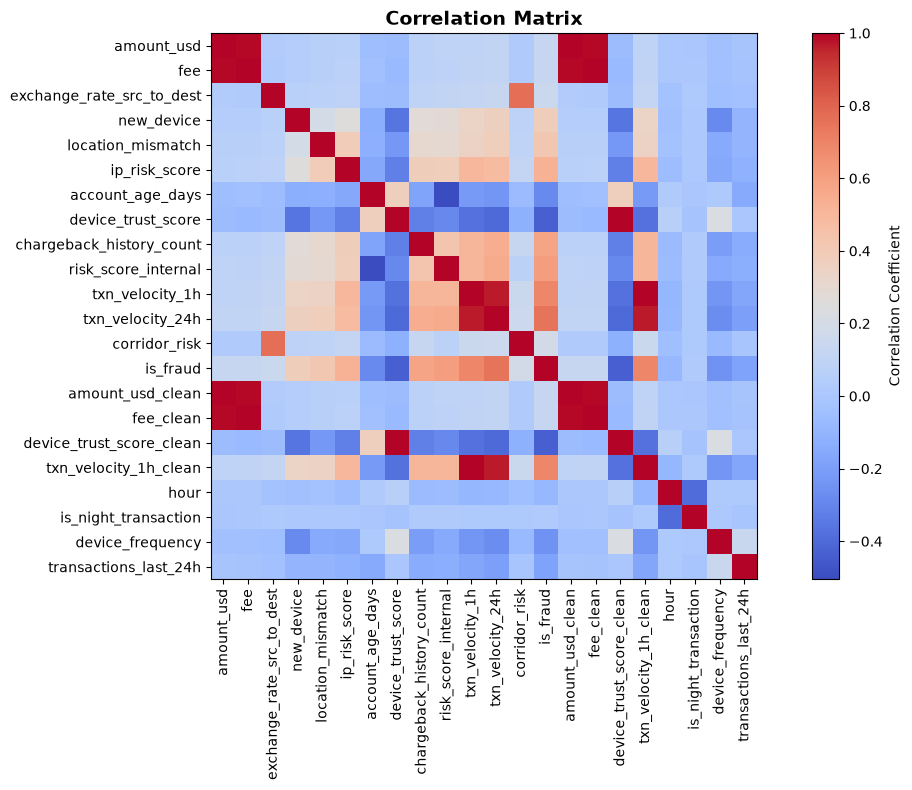

In [20928]:
import matplotlib.pyplot as plt
import pandas as pd

# Compute correlation matrix
pf = df.corr(numeric_only=True)

# Plot correlation matrix
plt.figure(figsize=(12, 8))
plt.imshow(pf, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlation Coefficient')

plt.xticks(range(len(pf.columns)), pf.columns, rotation=90)
plt.yticks(range(len(pf.columns)), pf.columns)

plt.title('Correlation Matrix', fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


Correlation Analysis of Numerical Variables

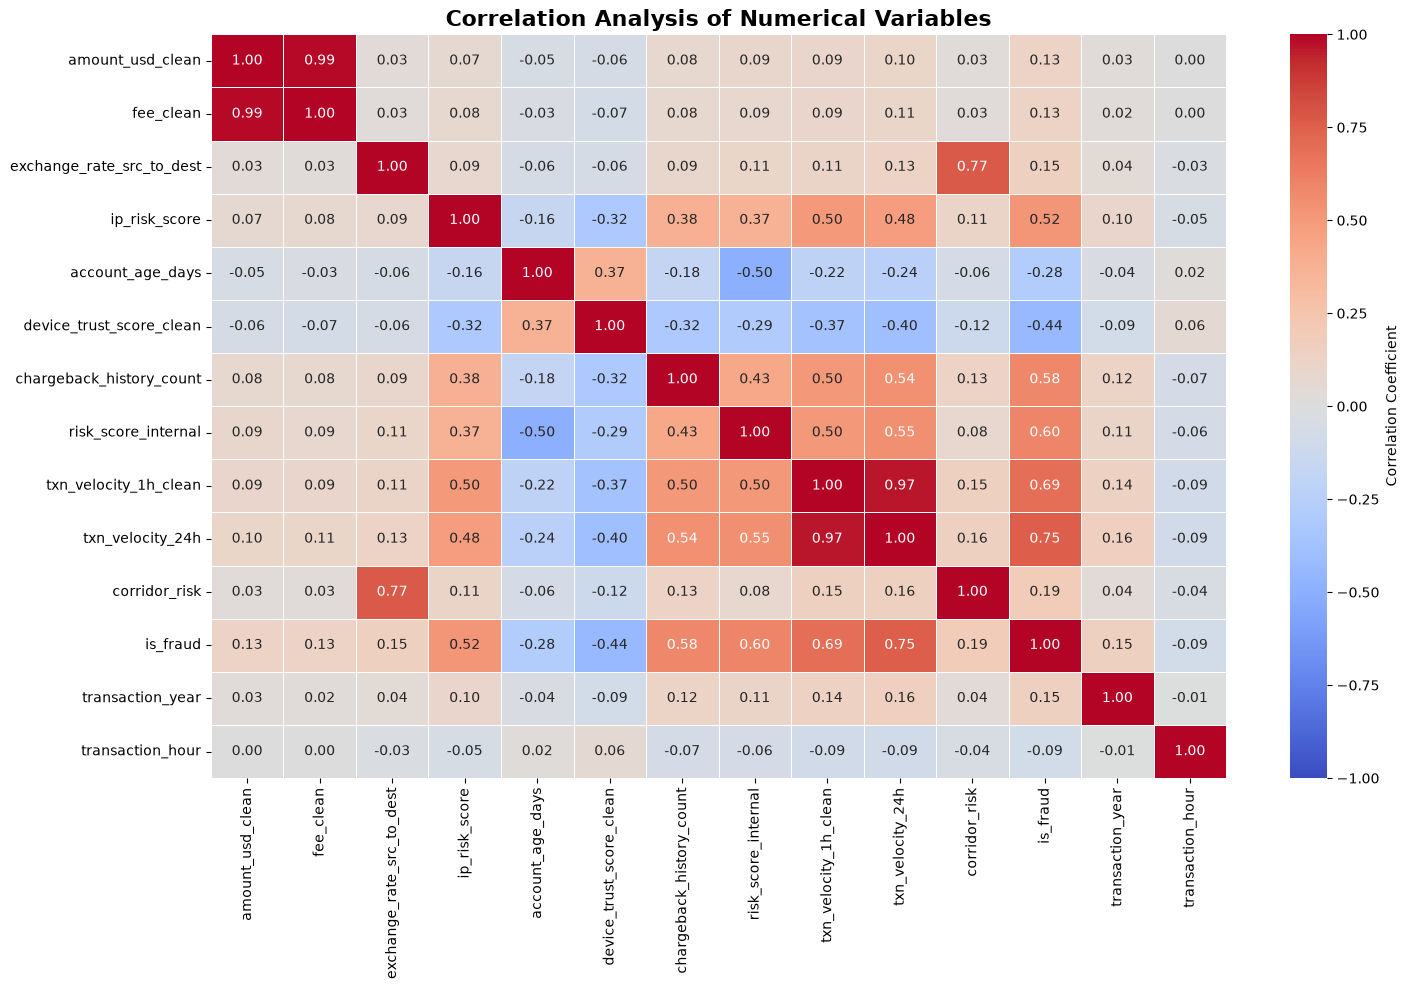

In [20937]:
# Compute correlation matrixnumerical and visualize with a heatmap

plt.figure(figsize=(15,10))
sns.heatmap(
    df_clean.corr(numeric_only=True),
    annot=True,
    fmt=".2f",          # show 2 decimal places
    vmin=-1, vmax=1,    # full correlation range
    cmap='coolwarm',    # ✅ changed to match correlation matrix
    linewidths=0.5,     # grid lines for readability
    cbar_kws={"label": "Correlation Coefficient"}
)
plt.title('Correlation Analysis of Numerical Variables', fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()
